# 04 Extra — CI Overlap Analysis & True β vs Estimated β̂ Diagnostics

## Objective
Extend the evaluation from Notebook 04 with two families of publication-ready plots that
examine **Confidence Interval Overlap** and **coefficient recovery fidelity** across the
full factorial design.

| Plot Family | Description |
|-------------|-------------|
| **CI Overlap Heatmaps** | Mean CI Overlap % (β₁…βₚ) by method, ρ, σ², N, p, and var_type |
| **True β vs β̂ 3×3 Grids** | Per-method scatter of true β vs estimated β̂ (OD & SD) across (ρ × σ²) facets, comparing N = 100 vs N = 1000 |
| **Extra Diagnostics** | Additional representative plots for deeper insight |

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, gc, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Publication-quality style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
})

METHOD_PALETTE = {"CART": "#e74c3c", "NORM": "#2ecc71", "PMM": "#3498db"}
METHOD_ORDER   = ["CART", "NORM", "PMM"]

result_dir = os.path.join("..", "results")
fig_dir    = os.path.join(result_dir, "figures")
os.makedirs(fig_dir, exist_ok=True)
print("Ready.")

Ready.


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────
parquet_path = os.path.join(result_dir, "aggregated_model_metrics.parquet")
df = pd.read_parquet(parquet_path)
print(f"Loaded {len(df):,} rows × {len(df.columns)} cols")

# True beta vector from config: intercept=1, all slopes=1
TRUE_BETA = np.array([1.0] * 11)  # beta_0 … beta_10

# Column groups
beta_od_cols = sorted([c for c in df.columns if c.startswith("beta_od_")])
beta_sd_cols = sorted([c for c in df.columns if c.startswith("beta_sd_")])
se_od_cols   = sorted([c for c in df.columns if c.startswith("se_od_")])
se_sd_cols   = sorted([c for c in df.columns if c.startswith("se_sd_")])

# Slope-only (exclude intercept at index 0)
beta_od_slope = [c for c in beta_od_cols if c != "beta_od_0"]
beta_sd_slope = [c for c in beta_sd_cols if c != "beta_sd_0"]
se_od_slope   = [c for c in se_od_cols   if c != "se_od_0"]
se_sd_slope   = [c for c in se_sd_cols   if c != "se_sd_0"]

print(f"Slopes: {len(beta_od_slope)} beta cols, {len(se_od_slope)} SE cols")
df.head(2)

Loaded 2,160 rows × 75 cols
Slopes: 10 beta cols, 10 SE cols


,method,var_type,N,p,rho,sigma_2,iter,adj_r2_od,adj_r2_sd,beta_od_0,...,pval_sd_1,pval_sd_2,pval_sd_3,pval_sd_4,pval_sd_5,pval_sd_6,pval_sd_7,pval_sd_8,pval_sd_9,pval_sd_10
0,cart,binary,100,3,0.0,1.0,1,0.495252,0.499083,1.080615,...,2.589290e-04,5.885801e-13,0.013436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cart,binary,100,3,0.0,1.0,2,0.427138,0.499006,0.774386,...,1.171810e-09,2.660917e-08,0.000075,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## Compute CI Overlap %

For each predictor $j = 1 \ldots p$:

$$\text{CI}_{OD,j} = \left[ \hat{\beta}_{OD,j} - 1.96\,SE_{OD,j},\; \hat{\beta}_{OD,j} + 1.96\,SE_{OD,j} \right]$$
$$\text{CI}_{SD,j} = \left[ \hat{\beta}_{SD,j} - 1.96\,SE_{SD,j},\; \hat{\beta}_{SD,j} + 1.96\,SE_{SD,j} \right]$$

**Overlap length:**
$$\text{overlap}_j = \max\!\left(0,\; \min(U_{OD}, U_{SD}) - \max(L_{OD}, L_{SD})\right)$$

**Overlap percentage** (Jaccard-style denominator = union span):
$$\text{CI Overlap \%}_j = \frac{\text{overlap}_j}{\max(U_{OD}, U_{SD}) - \min(L_{OD}, L_{SD})} \times 100$$

We average across all valid (non-NaN) slope predictors per scenario.

In [3]:
# ── Compute CI Overlap % per scenario ────────────────────────────────────────

bo = df[beta_od_slope].values
bs = df[beta_sd_slope].values
so = df[se_od_slope].values
ss = df[se_sd_slope].values

# 95 % CI bounds
L_od = bo - 1.96 * so
U_od = bo + 1.96 * so
L_sd = bs - 1.96 * ss
U_sd = bs + 1.96 * ss

# Overlap and union spans
overlap_len = np.maximum(0, np.minimum(U_od, U_sd) - np.maximum(L_od, L_sd))
union_len   = np.maximum(U_od, U_sd) - np.minimum(L_od, L_sd)

# Validity mask: both CIs must be finite and have positive width
valid = (
    ~np.isnan(bo) & ~np.isnan(bs) &
    ~np.isnan(so) & ~np.isnan(ss) &
    (so > 0) & (ss > 0) & (union_len > 0)
)

with np.errstate(divide="ignore", invalid="ignore"):
    ci_pct = np.where(valid, (overlap_len / union_len) * 100, np.nan)

# Mean across valid slope predictors per row
df["ci_overlap_pct"] = np.nanmean(ci_pct, axis=1)

print("CI Overlap % — summary by method:")
print(df.groupby("method")["ci_overlap_pct"].describe().round(2))

# Clean up
del L_od, U_od, L_sd, U_sd, overlap_len, union_len, ci_pct
gc.collect()

CI Overlap % — summary by method:
        count   mean    std    min    25%    50%    75%    max
method                                                        
cart    720.0  38.09  19.30   0.00  22.35  36.66  51.92  88.28
norm    720.0  55.03  12.65  13.72  47.53  55.95  63.35  90.77
pmm     720.0  58.02  12.64  11.37  50.98  58.65  65.97  90.90


20

---

## Plot 1 — Mean CI Overlap % by Method, ρ, and σ²

Three side-by-side heatmaps (one per method), with:
- **Rows** = ρ ∈ {0.0, 0.3, 0.6}
- **Columns** = σ² ∈ {1.0, 1.5, 2.0}

This is produced **4 times**: for each combination of `var_type` × `N`,
revealing how CI overlap behaves across all experimental axes.

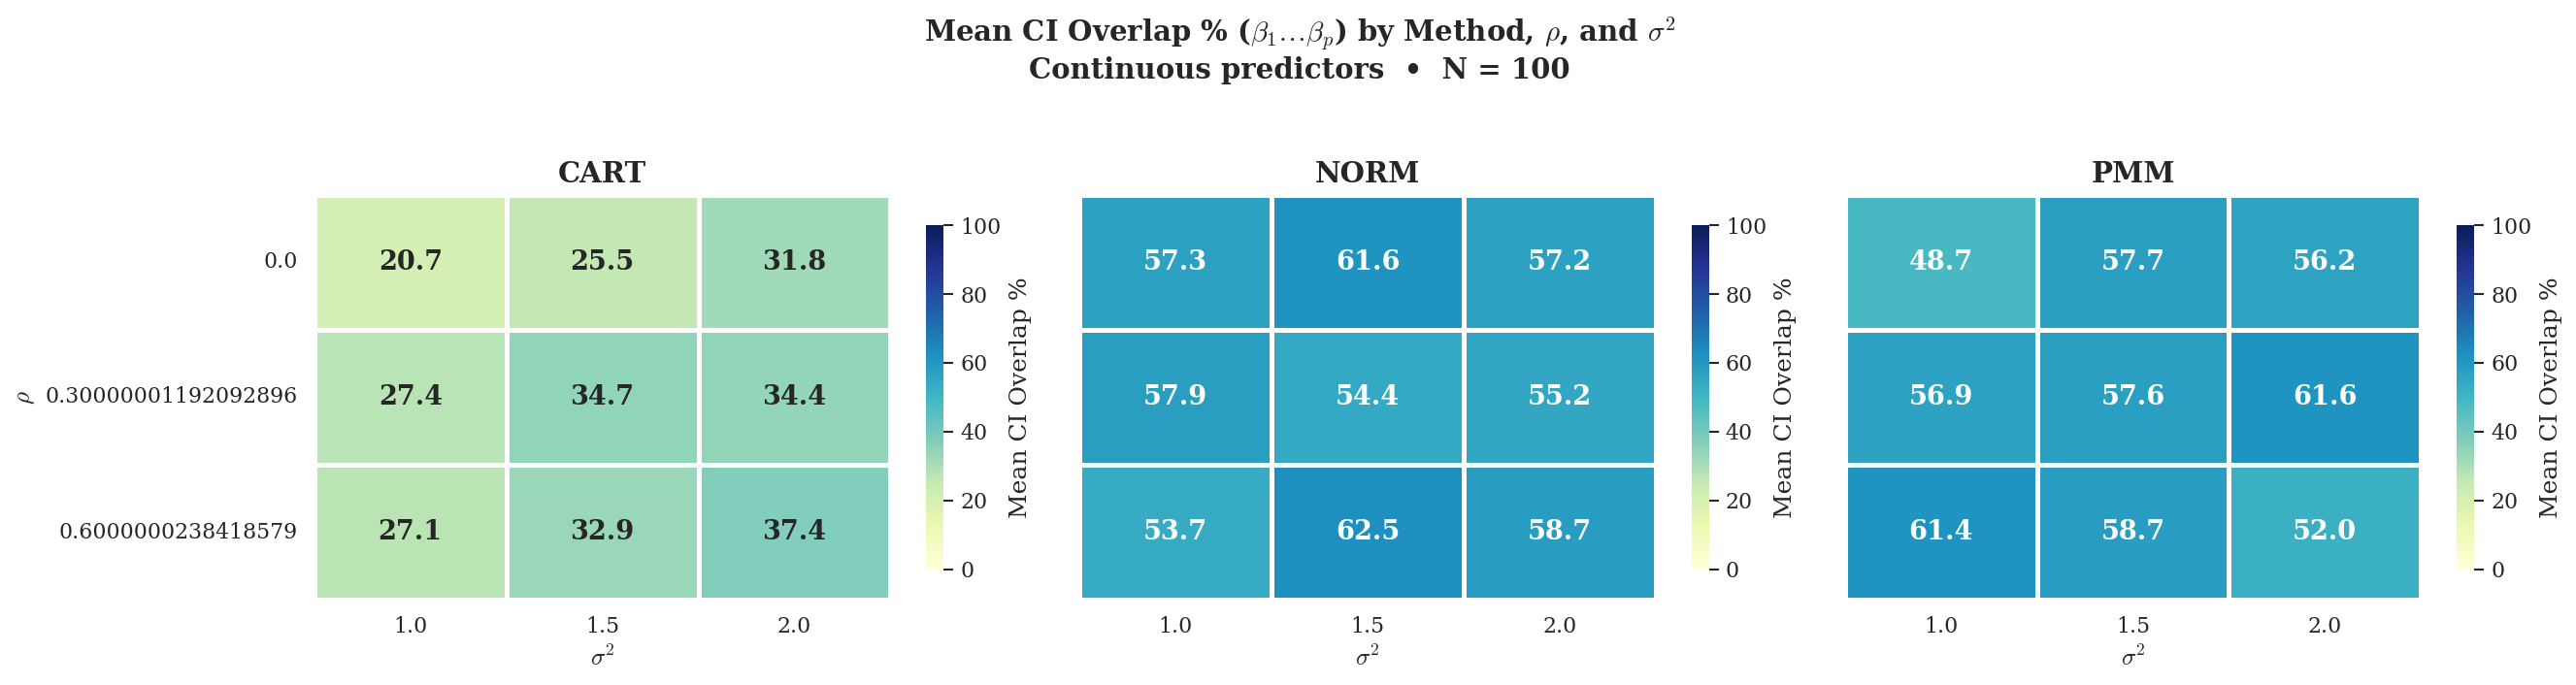

✓ Saved extra_ci_overlap_heatmap_continuous_N100.png


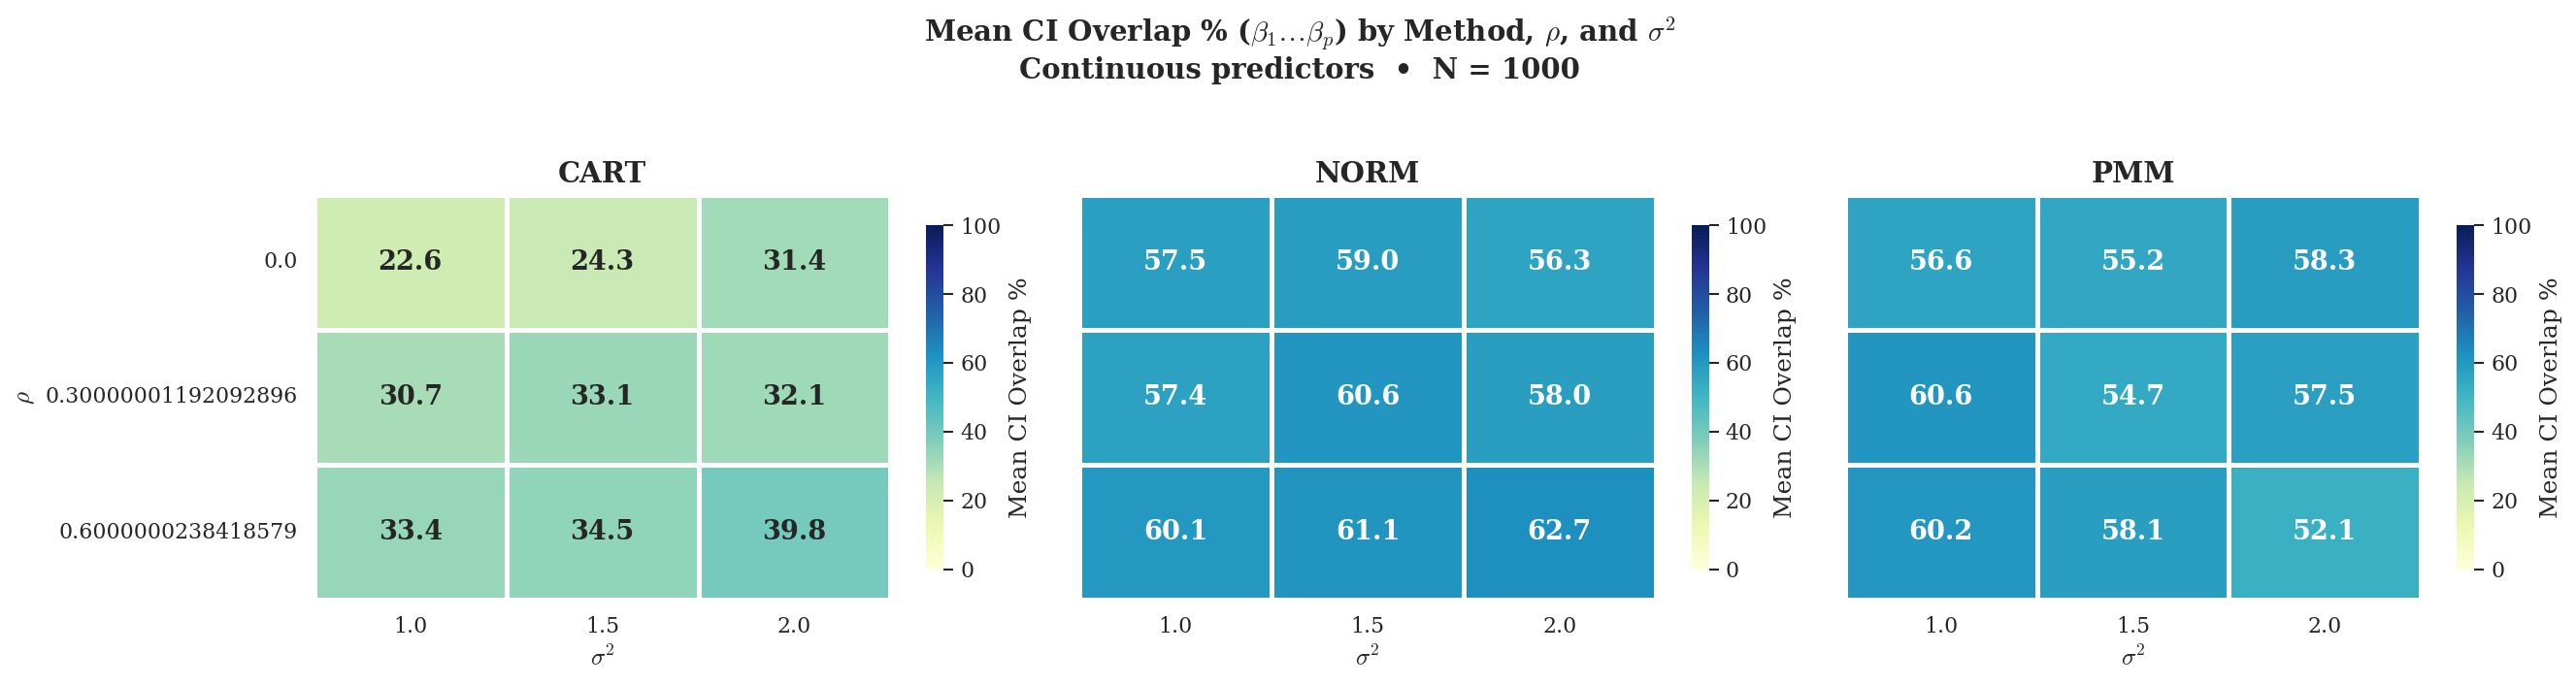

✓ Saved extra_ci_overlap_heatmap_continuous_N1000.png


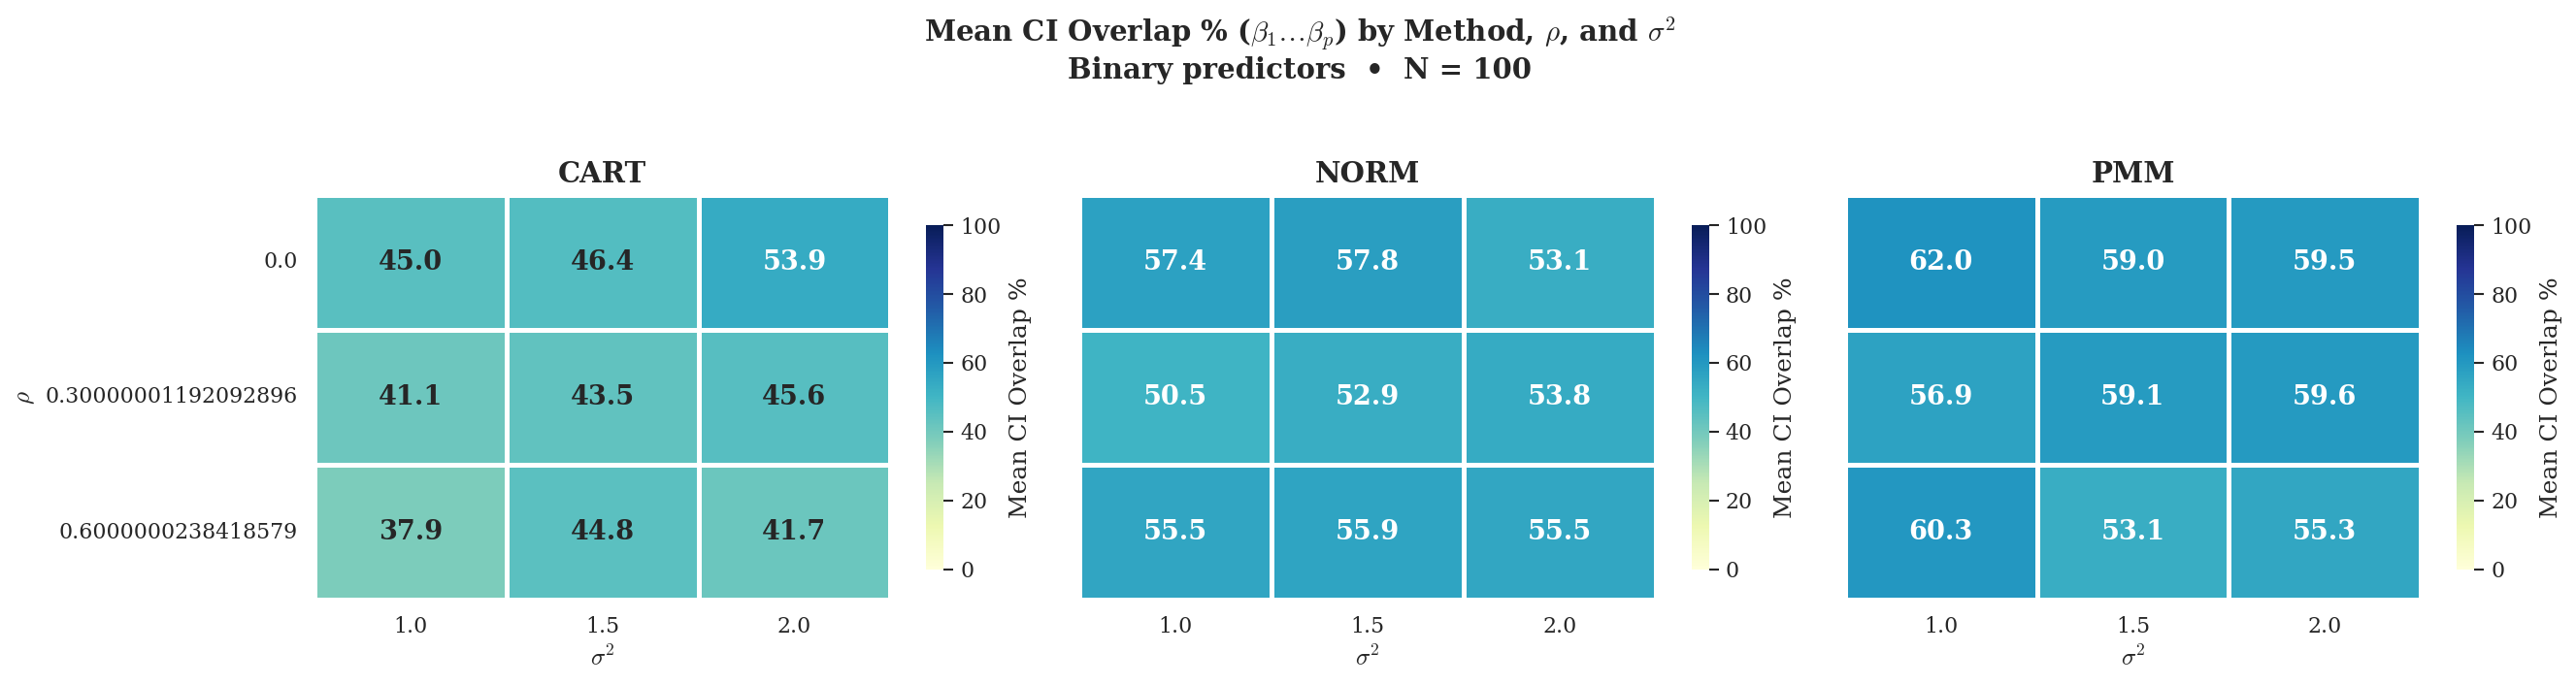

✓ Saved extra_ci_overlap_heatmap_binary_N100.png


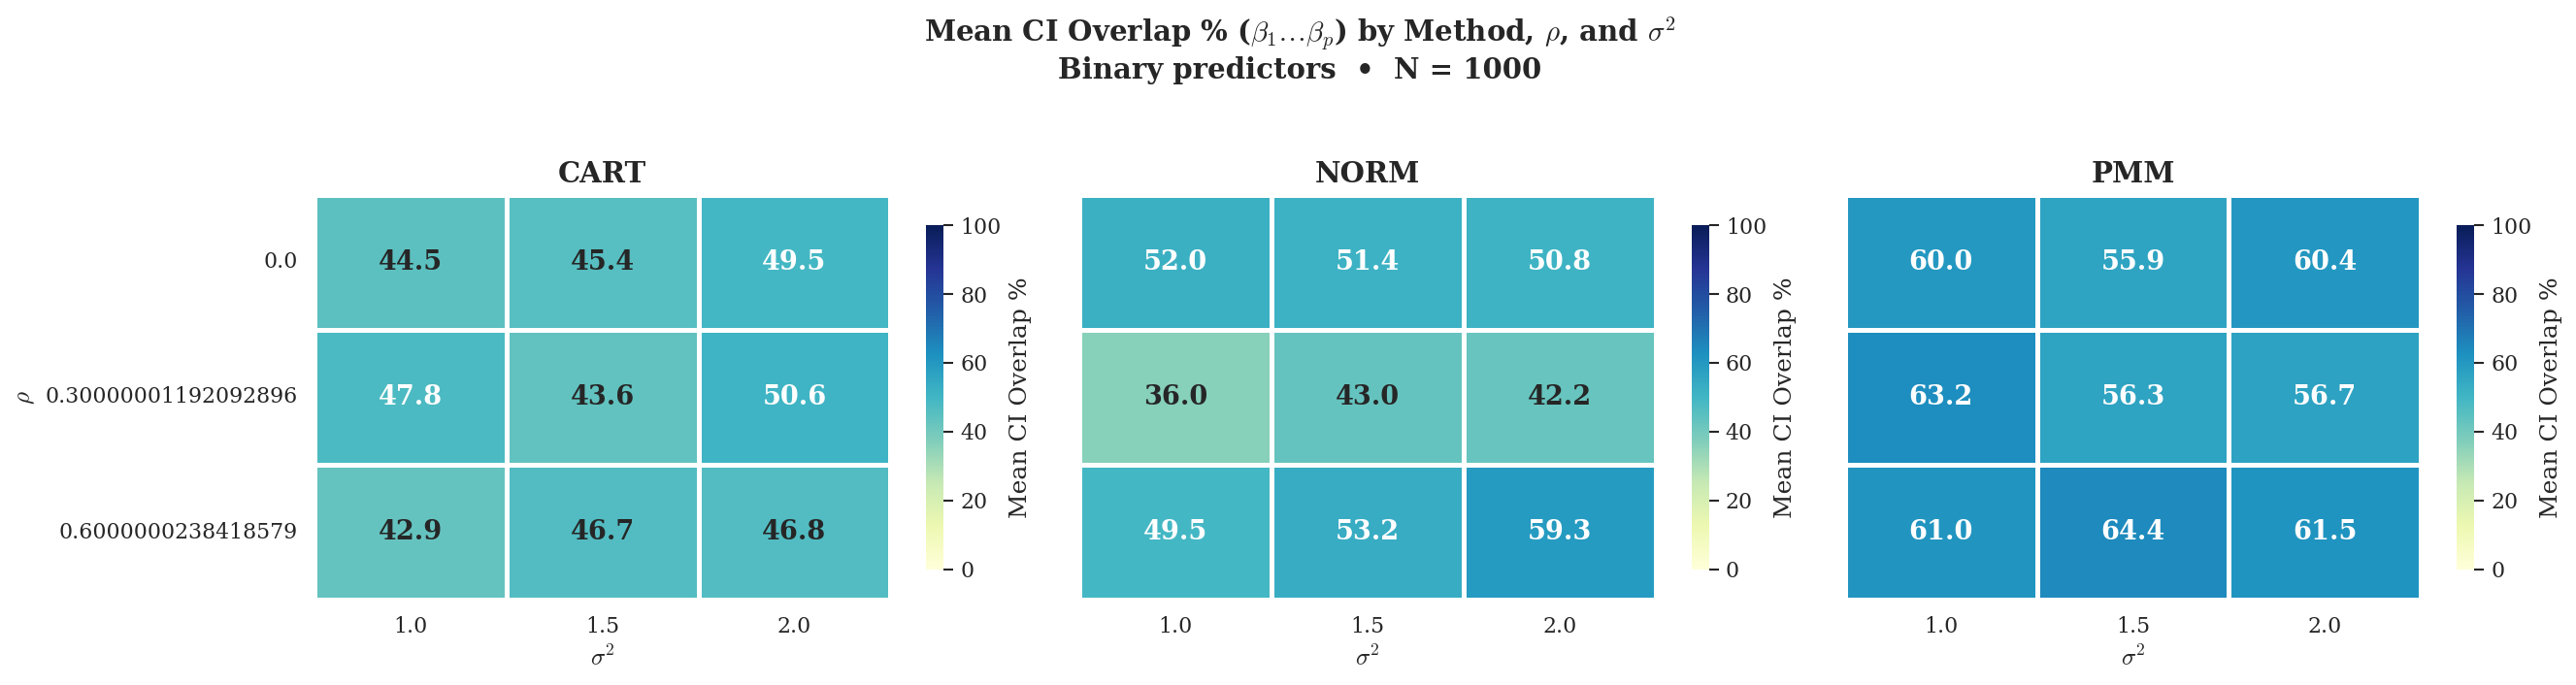

✓ Saved extra_ci_overlap_heatmap_binary_N1000.png


In [4]:
# ── Plot 1: CI Overlap heatmaps — 4 panels (var_type × N) ───────────────────

rho_vals   = sorted(df["rho"].unique())
sigma_vals = sorted(df["sigma_2"].unique())
methods    = ["cart", "norm", "pmm"]
method_labels = ["CART", "NORM", "PMM"]

for vt in ["continuous", "binary"]:
    for N_val in sorted(df["N"].unique()):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

        for ax, m, ml in zip(axes, methods, method_labels):
            sub = df[(df["method"] == m) & (df["var_type"] == vt) & (df["N"] == N_val)]
            pivot = (
                sub.groupby(["rho", "sigma_2"])["ci_overlap_pct"]
                   .mean()
                   .unstack("sigma_2")
                   .reindex(index=rho_vals, columns=sigma_vals)
            )
            sns.heatmap(
                pivot, ax=ax,
                annot=True, fmt=".1f",
                cmap="YlGnBu", vmin=0, vmax=100,
                linewidths=1.5, linecolor="white",
                cbar_kws={"label": "Mean CI Overlap %", "shrink": 0.85},
                annot_kws={"fontsize": 13, "fontweight": "bold"},
            )
            ax.set_title(ml, fontsize=14, fontweight="bold")
            ax.set_xlabel(r"$\sigma^2$", fontsize=12)
            ax.set_ylabel(r"$\rho$" if ax == axes[0] else "", fontsize=12)
            ax.tick_params(axis="y", labelrotation=0)

        fig.suptitle(
            rf"Mean CI Overlap % ($\beta_1 \ldots \beta_p$) by Method, $\rho$, and $\sigma^2$"
            f"\n{vt.capitalize()} predictors  •  N = {N_val}",
            fontsize=14, fontweight="bold", y=1.04,
        )
        plt.tight_layout()
        fname = f"extra_ci_overlap_heatmap_{vt}_N{N_val}.png"
        fig.savefig(os.path.join(fig_dir, fname))
        plt.show()
        print(f"✓ Saved {fname}")

---

## Plot 1b — CI Overlap Heatmap faceted by p (dimensionality)

Same structure as Plot 1 but now split by **p ∈ {3, 10}** to show how
dimensionality interacts with CI preservation.

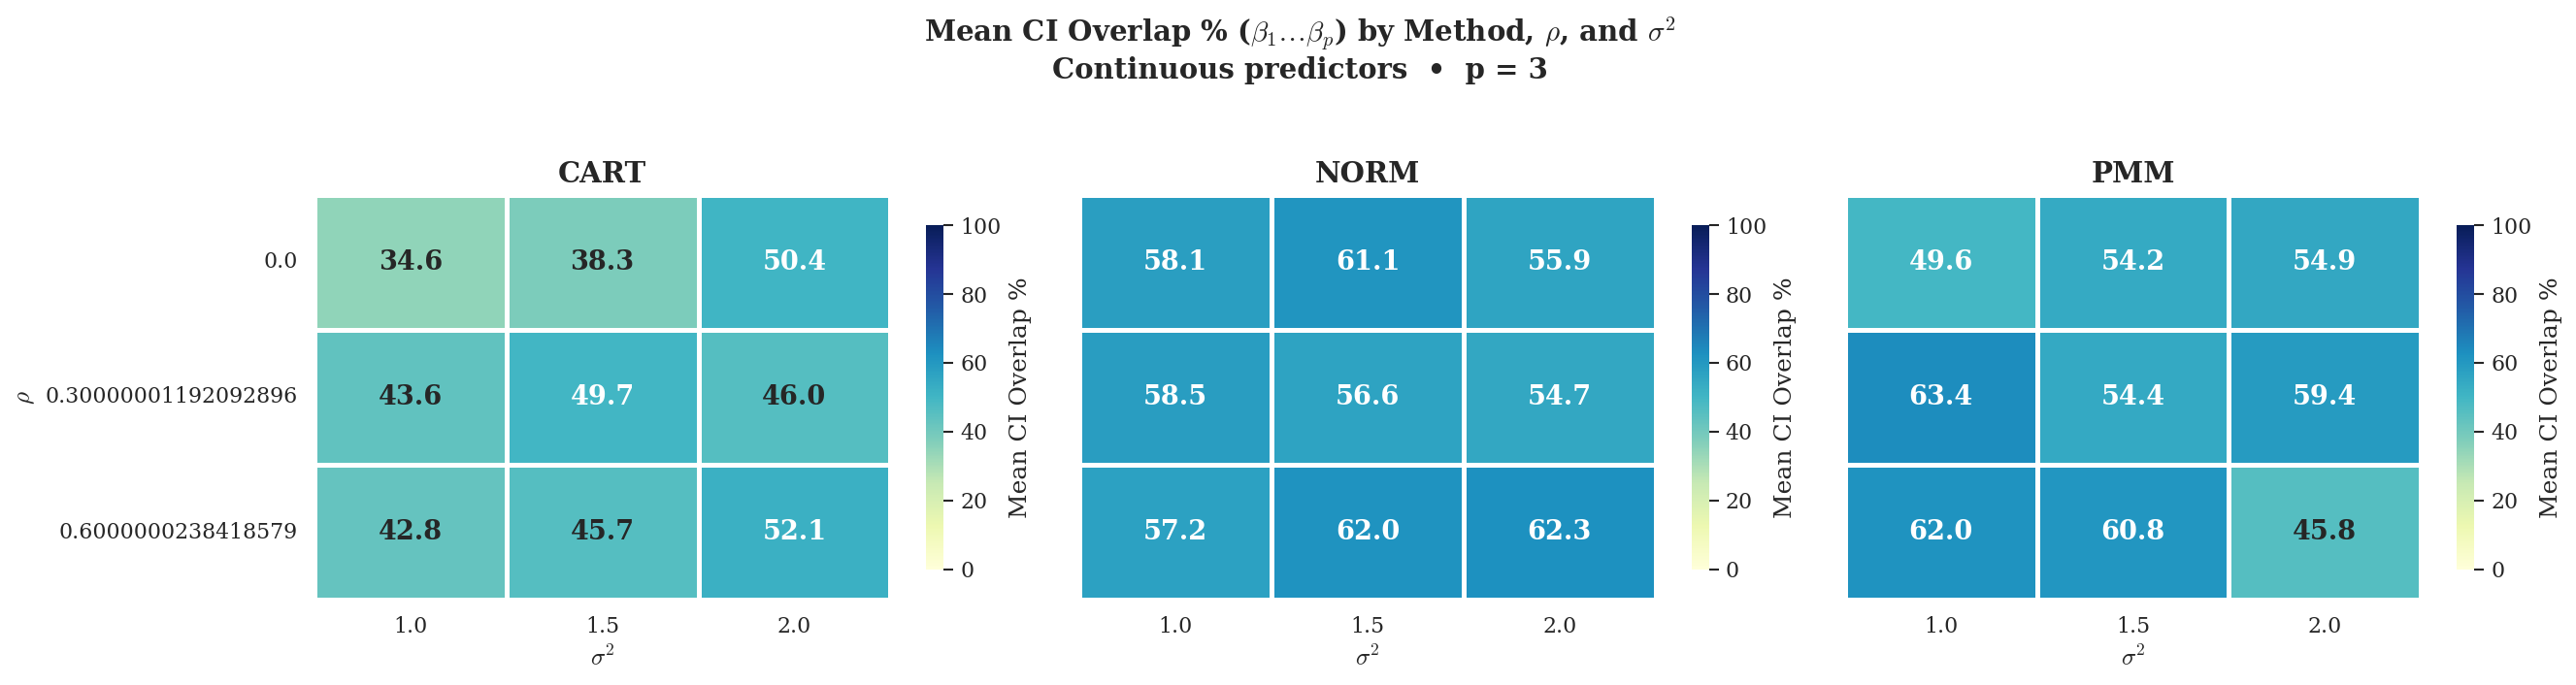

✓ Saved extra_ci_overlap_heatmap_continuous_p3.png


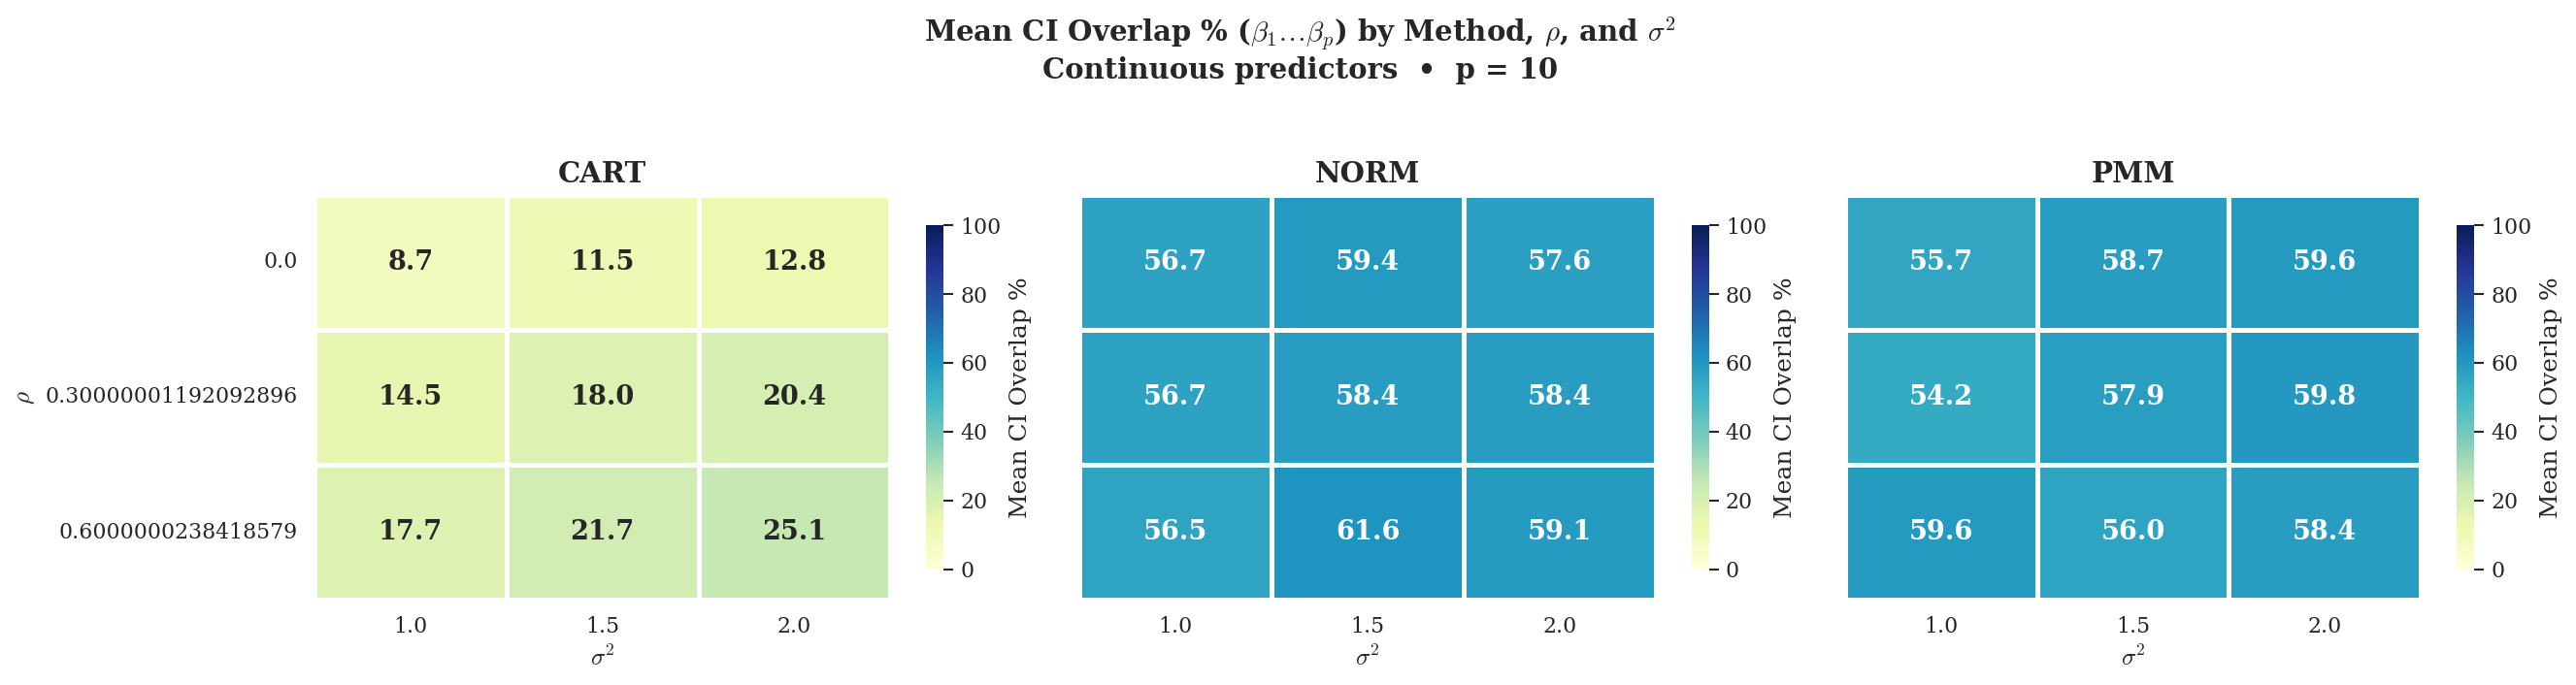

✓ Saved extra_ci_overlap_heatmap_continuous_p10.png


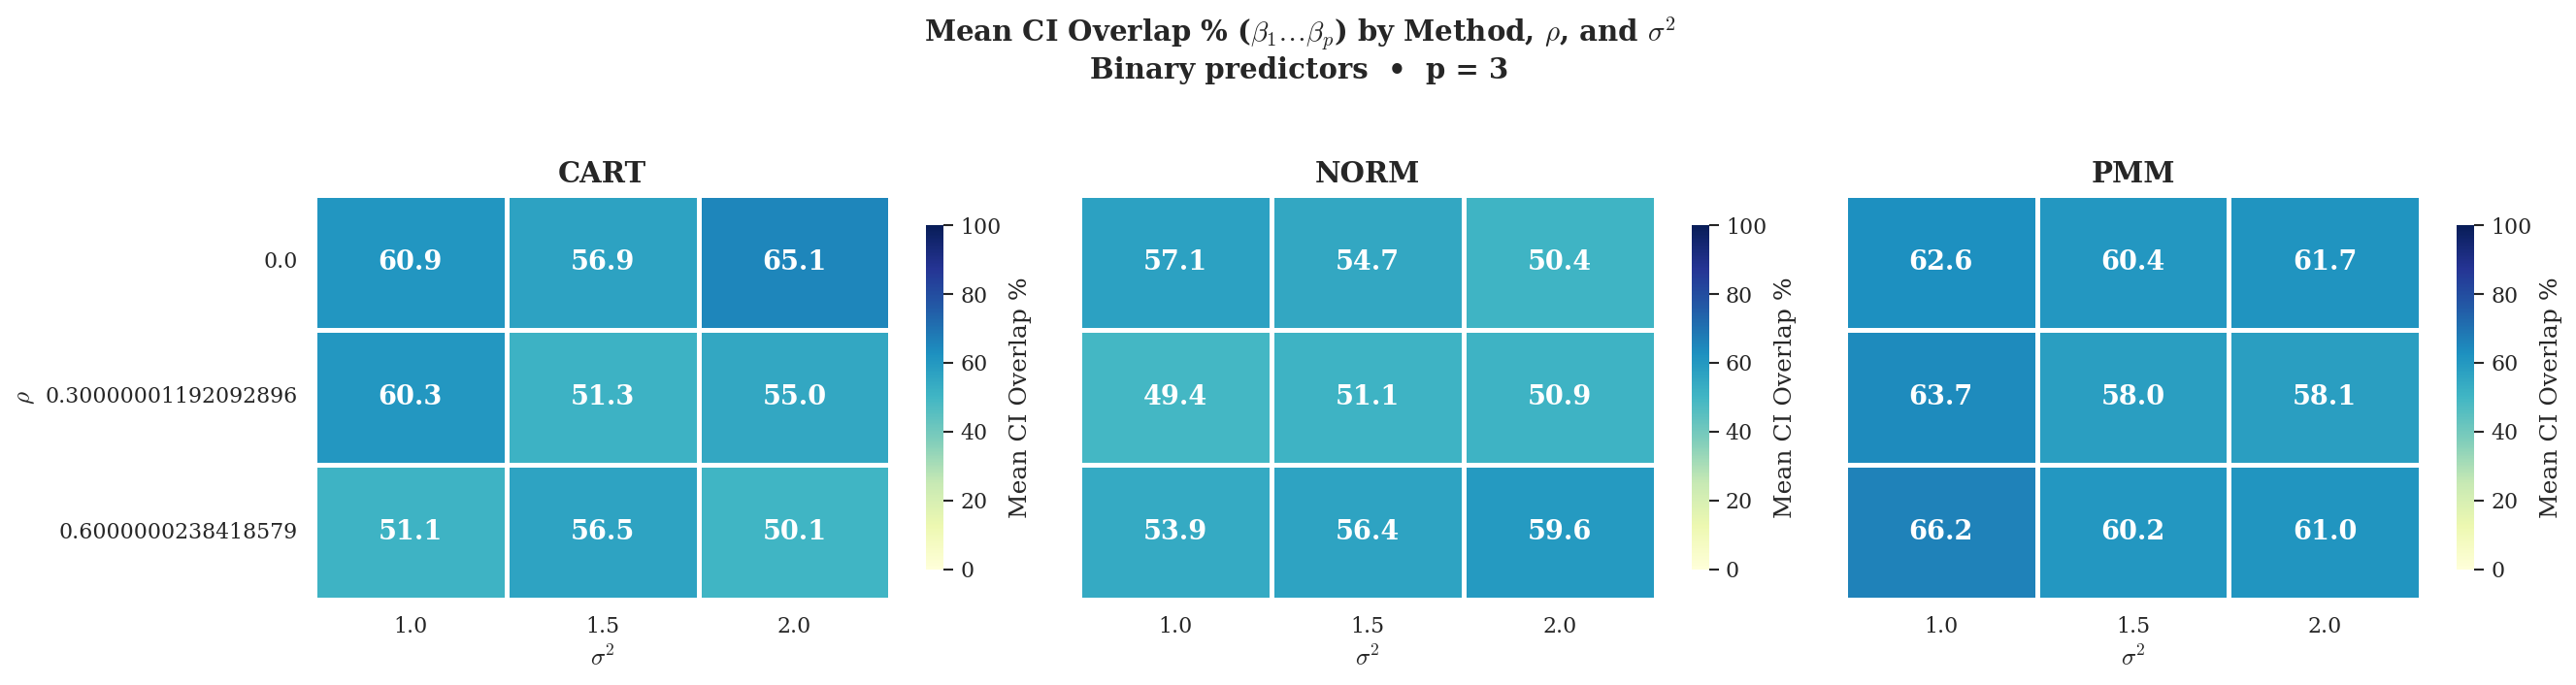

✓ Saved extra_ci_overlap_heatmap_binary_p3.png


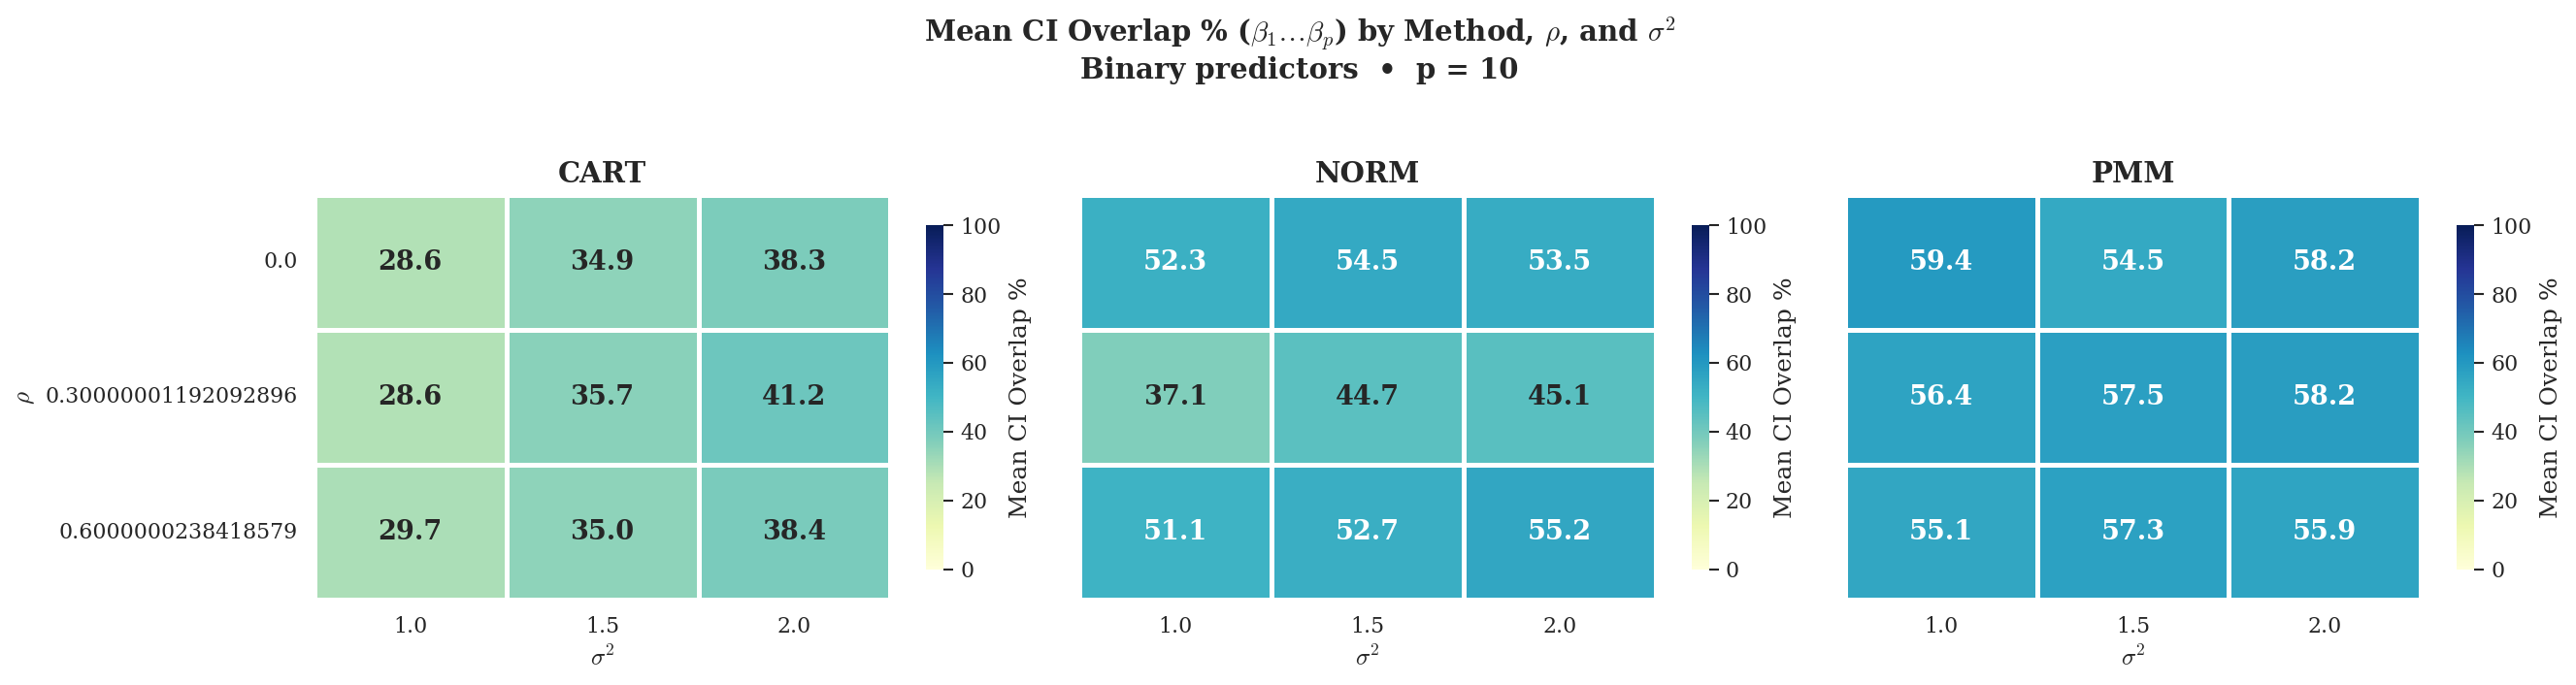

✓ Saved extra_ci_overlap_heatmap_binary_p10.png


In [5]:
# ── Plot 1b: CI Overlap heatmaps faceted by p ────────────────────────────────

for vt in ["continuous", "binary"]:
    for p_val in sorted(df["p"].unique()):
        fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

        for ax, m, ml in zip(axes, methods, method_labels):
            sub = df[(df["method"] == m) & (df["var_type"] == vt) & (df["p"] == p_val)]
            pivot = (
                sub.groupby(["rho", "sigma_2"])["ci_overlap_pct"]
                   .mean()
                   .unstack("sigma_2")
                   .reindex(index=rho_vals, columns=sigma_vals)
            )
            sns.heatmap(
                pivot, ax=ax,
                annot=True, fmt=".1f",
                cmap="YlGnBu", vmin=0, vmax=100,
                linewidths=1.5, linecolor="white",
                cbar_kws={"label": "Mean CI Overlap %", "shrink": 0.85},
                annot_kws={"fontsize": 13, "fontweight": "bold"},
            )
            ax.set_title(ml, fontsize=14, fontweight="bold")
            ax.set_xlabel(r"$\sigma^2$", fontsize=12)
            ax.set_ylabel(r"$\rho$" if ax == axes[0] else "", fontsize=12)
            ax.tick_params(axis="y", labelrotation=0)

        fig.suptitle(
            rf"Mean CI Overlap % ($\beta_1 \ldots \beta_p$) by Method, $\rho$, and $\sigma^2$"
            f"\n{vt.capitalize()} predictors  •  p = {p_val}",
            fontsize=14, fontweight="bold", y=1.04,
        )
        plt.tight_layout()
        fname = f"extra_ci_overlap_heatmap_{vt}_p{p_val}.png"
        fig.savefig(os.path.join(fig_dir, fname))
        plt.show()
        print(f"✓ Saved {fname}")

---

## Plot 1c — Grand CI Overlap Heatmap (N × p × method)

A single figure with a 2×2 outer grid (rows = N, cols = p),
each cell containing 3 mini-heatmaps (ρ × σ²) for the 3 methods.
This is the **definitive summary** of CI overlap across ALL experimental factors.

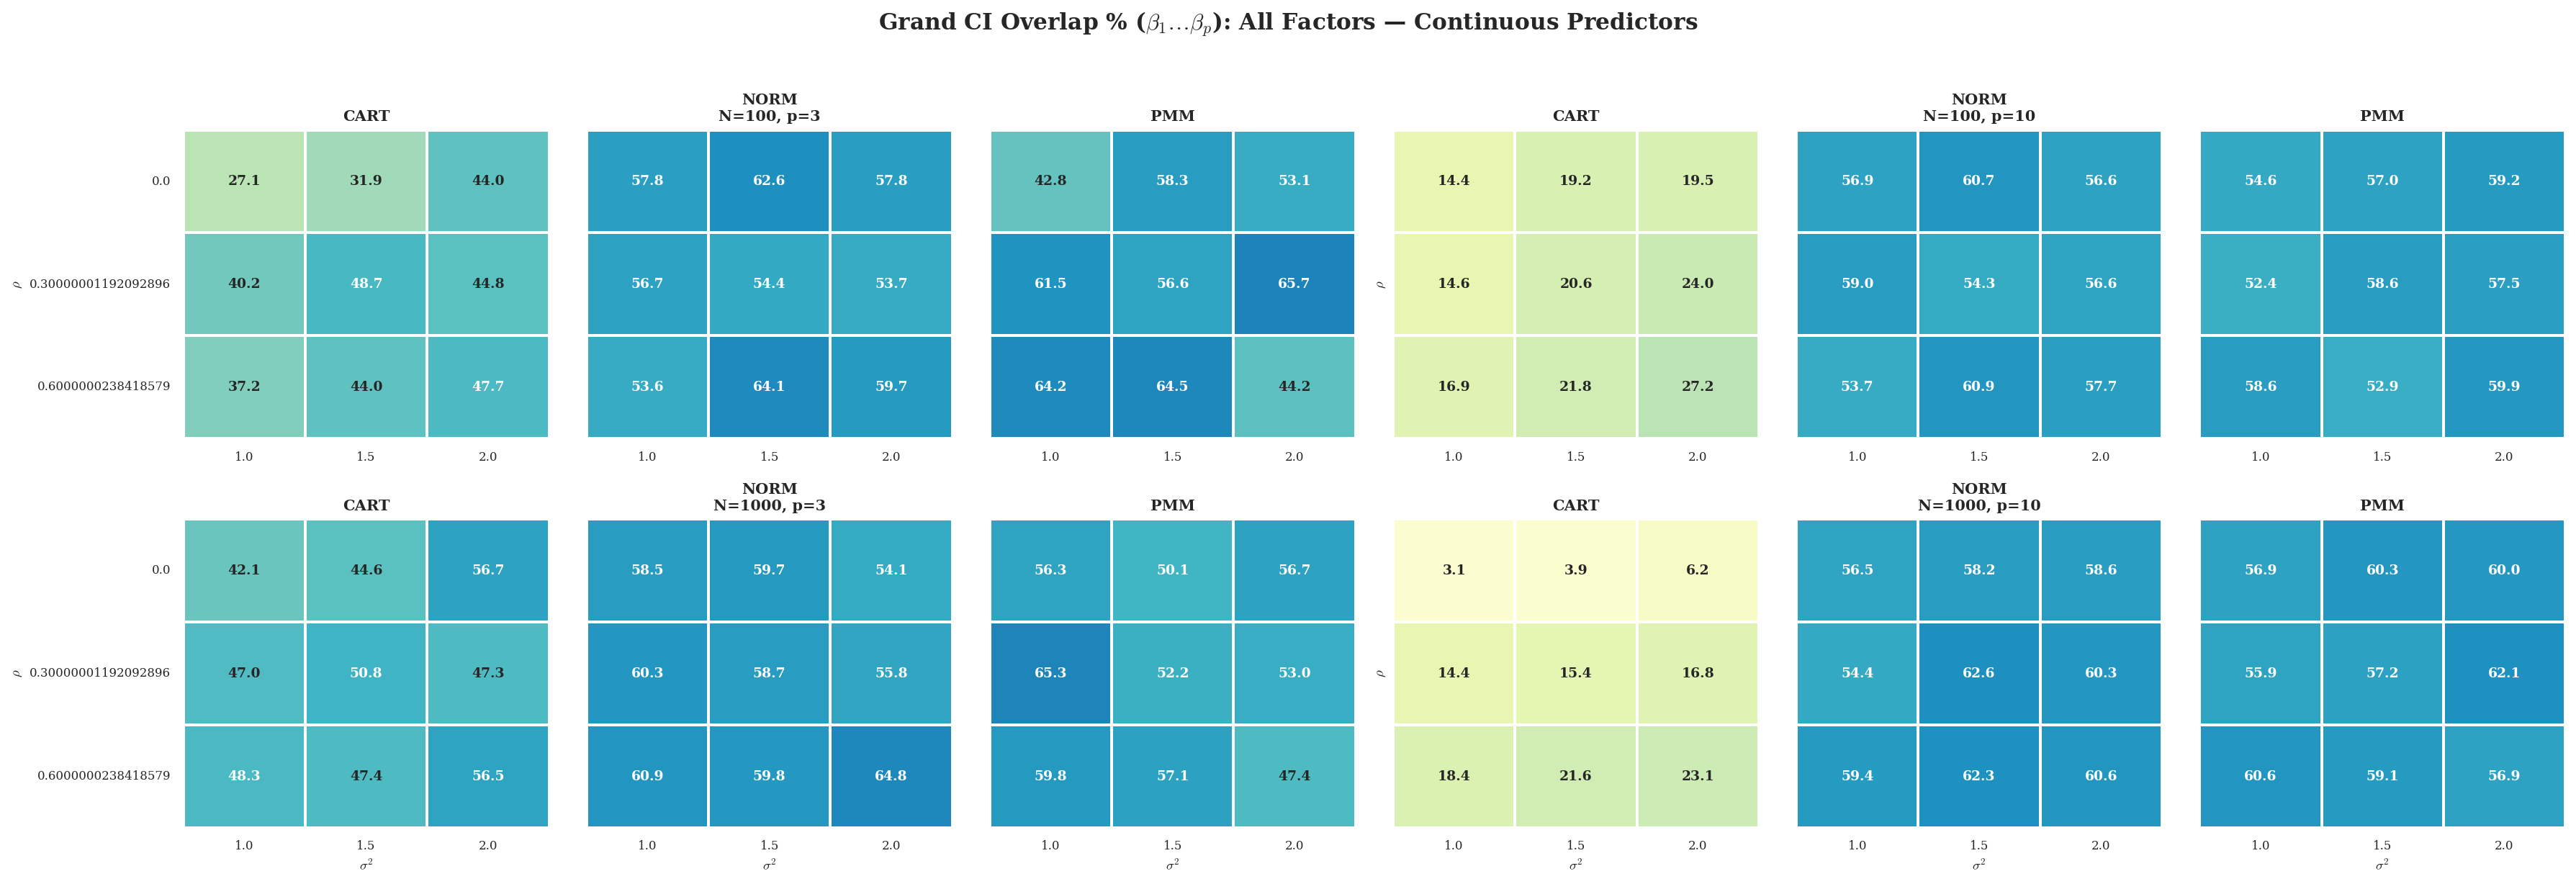

✓ Saved extra_ci_overlap_grand_continuous.png


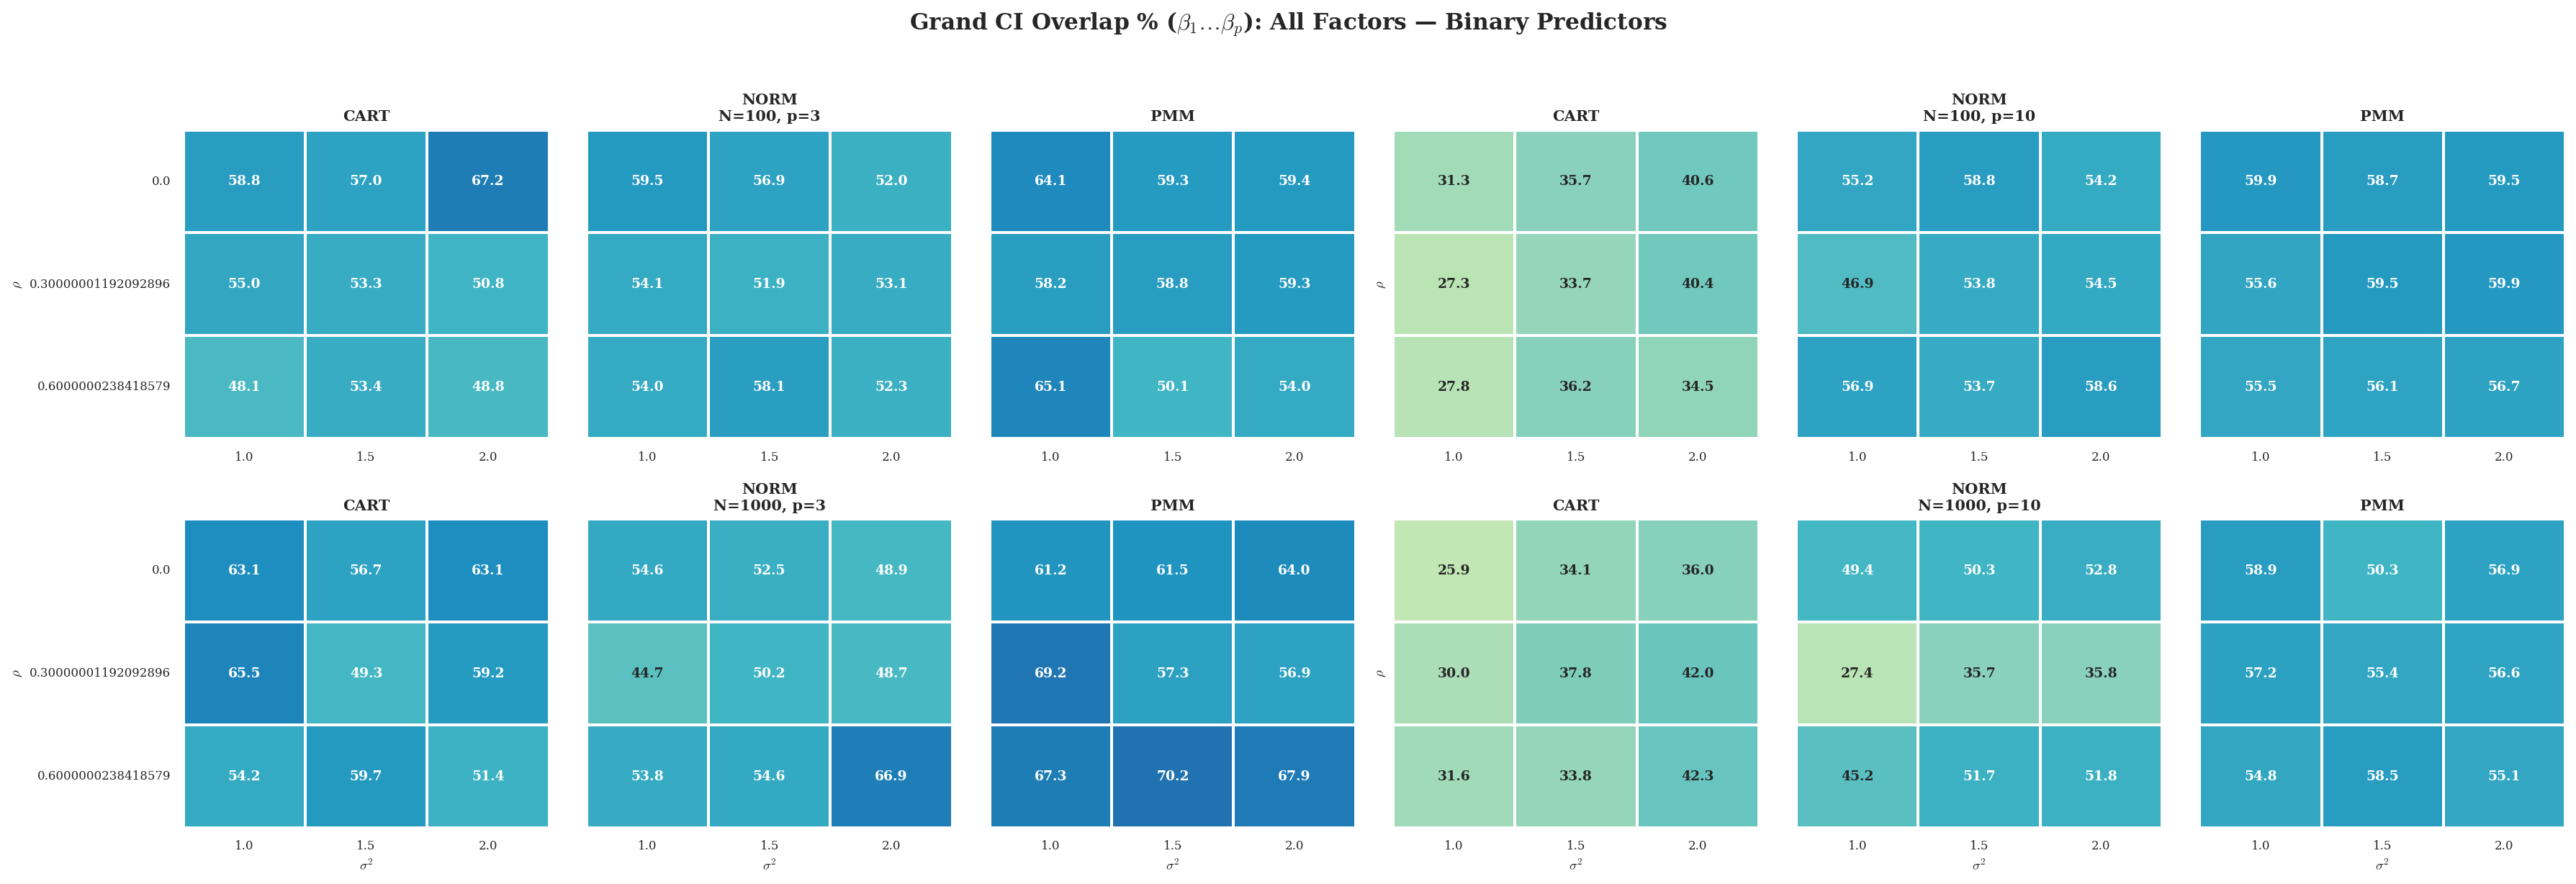

✓ Saved extra_ci_overlap_grand_binary.png


In [6]:
# ── Plot 1c: Grand 2×2 CI Overlap summary (N × p) ───────────────────────────

N_vals = sorted(df["N"].unique())
p_vals = sorted(df["p"].unique())

for vt in ["continuous", "binary"]:
    fig, outer_axes = plt.subplots(
        len(N_vals), len(p_vals) * 3,
        figsize=(24, 3.5 * len(N_vals) + 1),
        sharey=True,
    )

    for ni, N_val in enumerate(N_vals):
        for pi, p_val in enumerate(p_vals):
            for mi, (m, ml) in enumerate(zip(methods, method_labels)):
                ax = outer_axes[ni, pi * 3 + mi]
                sub = df[
                    (df["method"] == m) &
                    (df["var_type"] == vt) &
                    (df["N"] == N_val) &
                    (df["p"] == p_val)
                ]
                pivot = (
                    sub.groupby(["rho", "sigma_2"])["ci_overlap_pct"]
                       .mean()
                       .unstack("sigma_2")
                       .reindex(index=rho_vals, columns=sigma_vals)
                )
                sns.heatmap(
                    pivot, ax=ax,
                    annot=True, fmt=".1f",
                    cmap="YlGnBu", vmin=0, vmax=100,
                    linewidths=1, linecolor="white",
                    cbar=False,
                    annot_kws={"fontsize": 9, "fontweight": "bold"},
                )
                title = f"{ml}"
                if mi == 1:
                    title += f"\nN={N_val}, p={p_val}"
                ax.set_title(title, fontsize=10, fontweight="bold")
                ax.set_xlabel(r"$\sigma^2$" if ni == len(N_vals) - 1 else "", fontsize=9)
                ax.set_ylabel(r"$\rho$" if mi == 0 else "", fontsize=9)
                ax.tick_params(axis="both", labelsize=8)
                ax.tick_params(axis="y", labelrotation=0)

    fig.suptitle(
        rf"Grand CI Overlap % ($\beta_1 \ldots \beta_p$): All Factors — {vt.capitalize()} Predictors",
        fontsize=15, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    fname = f"extra_ci_overlap_grand_{vt}.png"
    fig.savefig(os.path.join(fig_dir, fname))
    plt.show()
    print(f"✓ Saved {fname}")

---

## Plot 2 — True β vs Estimated β̂: 3×3 Grids (per Method)

For each synthesis method, a **3×3 figure** where:
- **Rows** = ρ ∈ {0.0, 0.3, 0.6}
- **Columns** = σ² ∈ {1.0, 1.5, 2.0}

Each cell contains:
- Scatter of **true β** (x-axis) vs **estimated β̂** (y-axis)
- **Blue dots** = OD estimates at N = 100
- **Red dots** = SD estimates at N = 100
- **Blue ×** = OD estimates at N = 1000
- **Red ×** = SD estimates at N = 1000
- Dashed **y = x** reference line (perfect recovery)

Since all true β slopes = 1, the x-coordinates are jittered by predictor index
to avoid overplotting. This reveals systematic bias (deviation from diagonal) and
variance (spread) for each experimental condition.

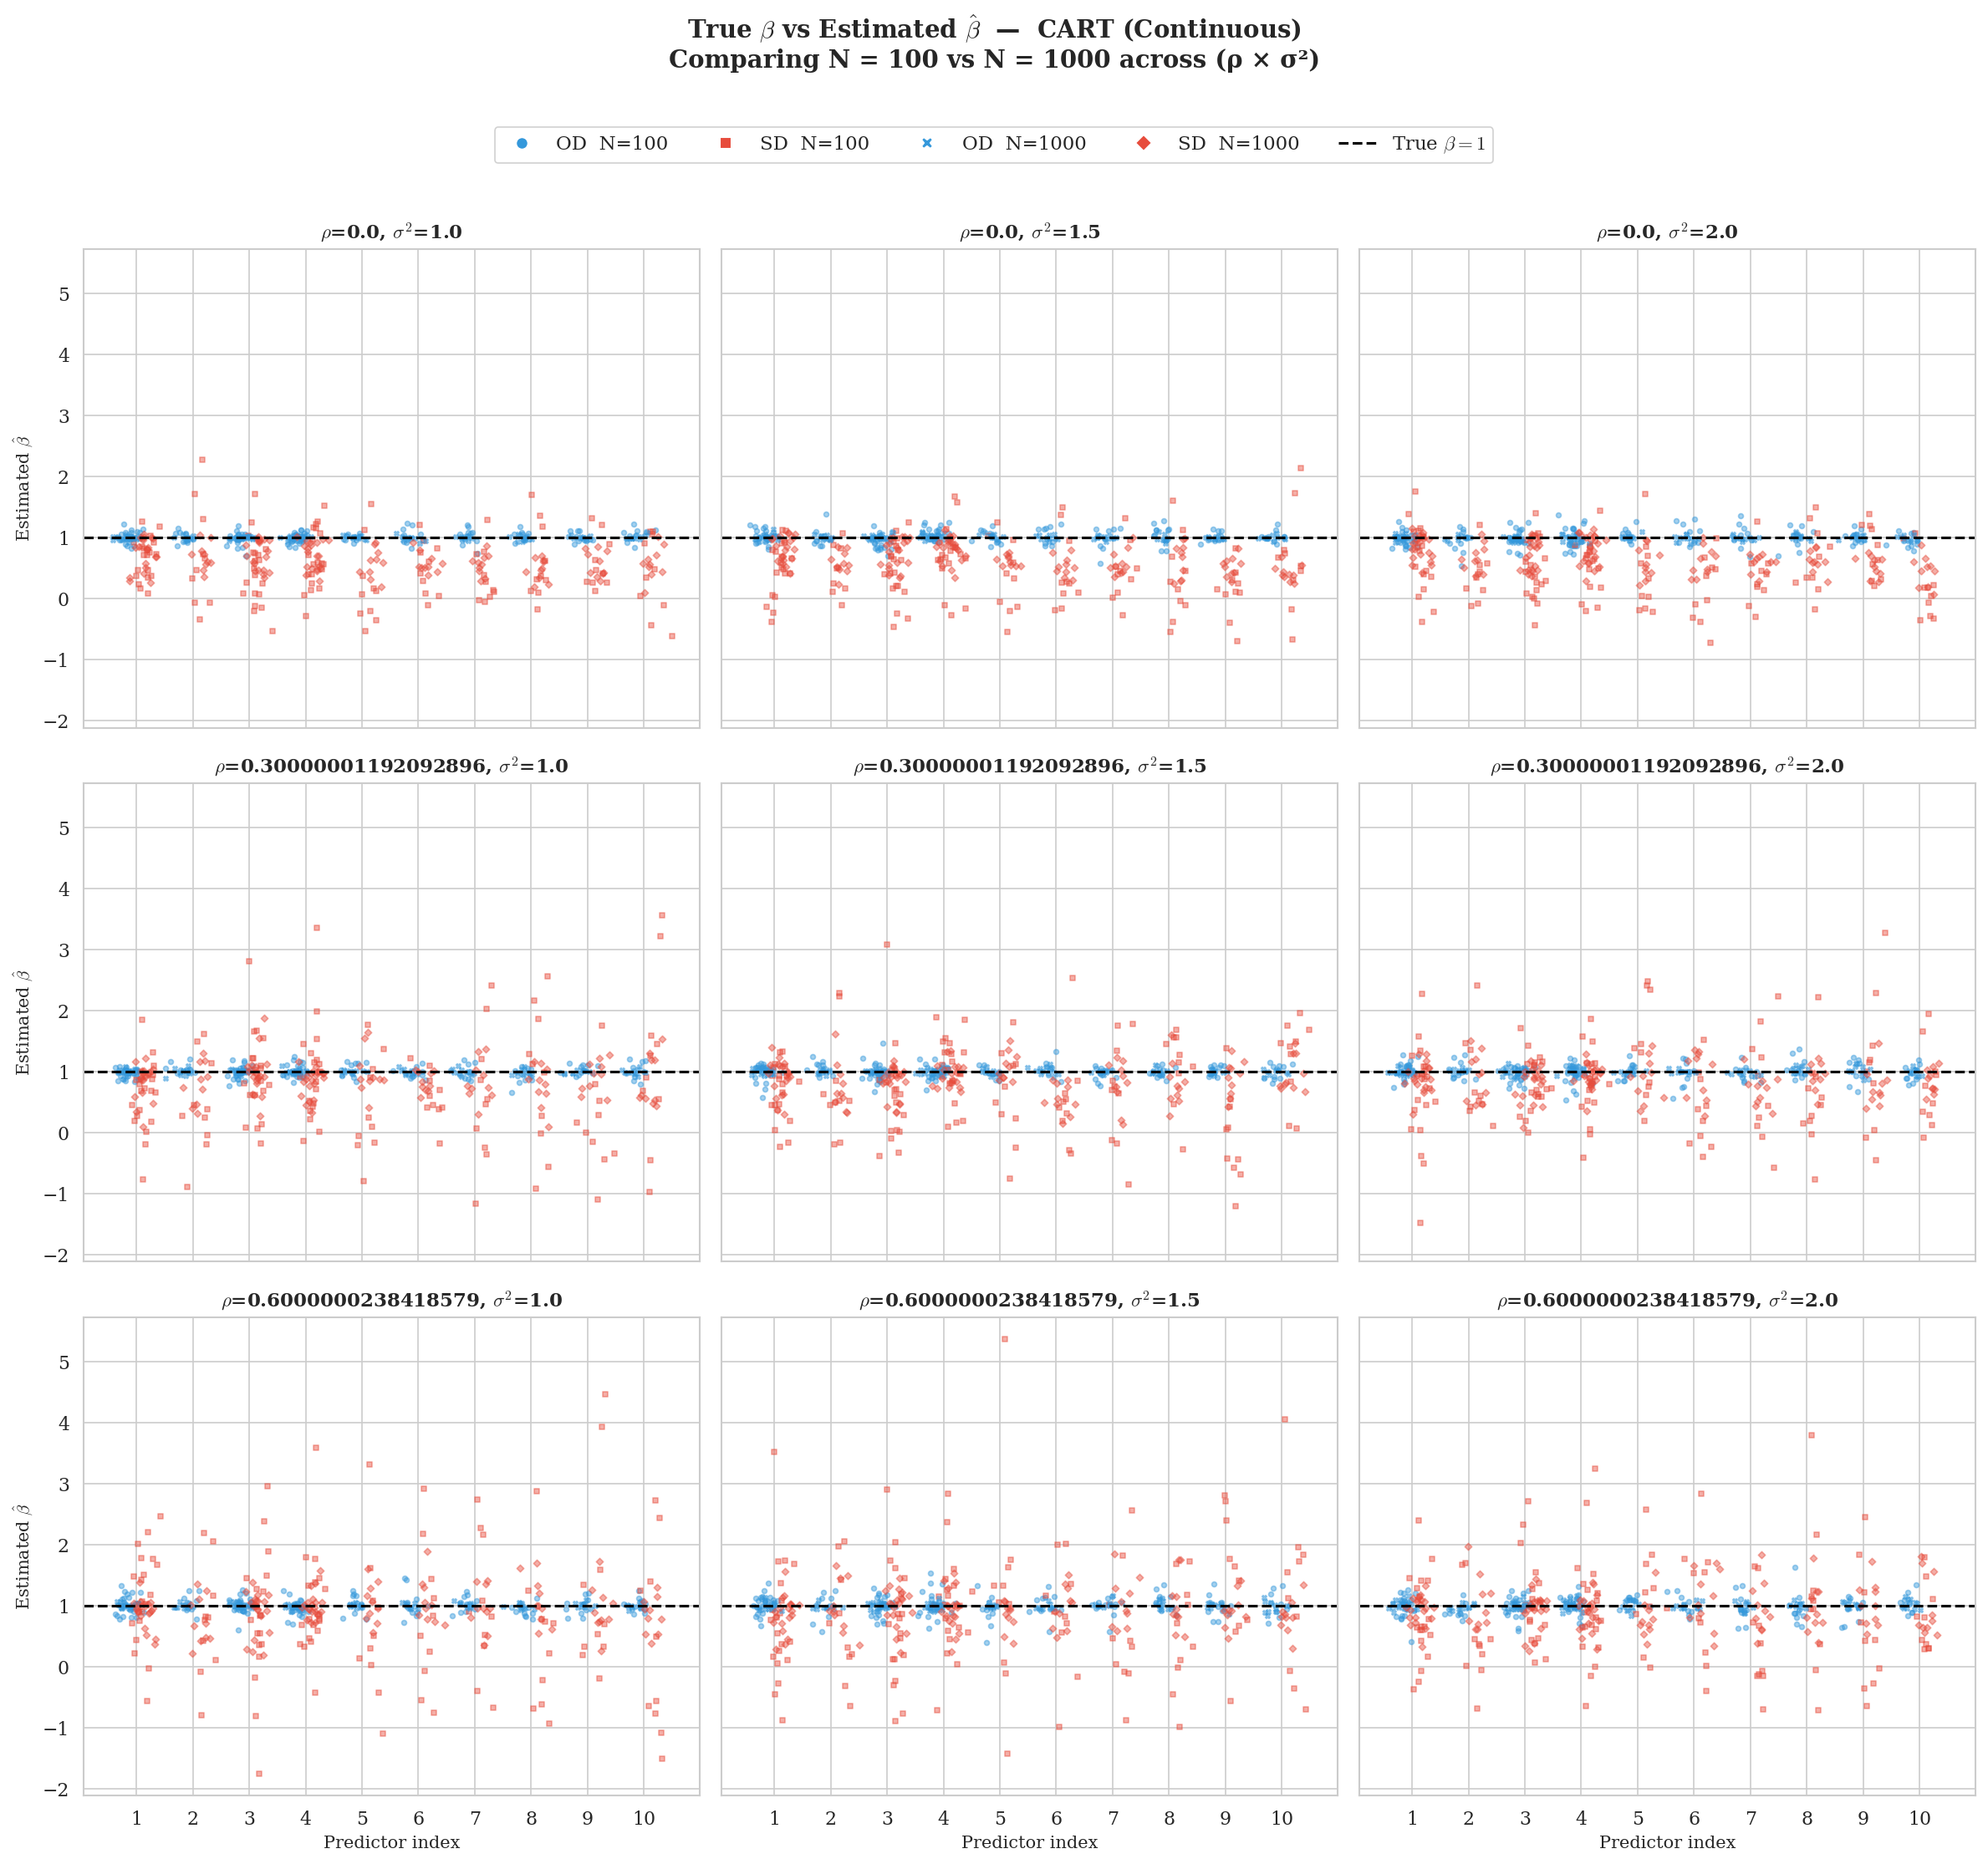

✓ Saved extra_true_vs_est_cart_continuous.png


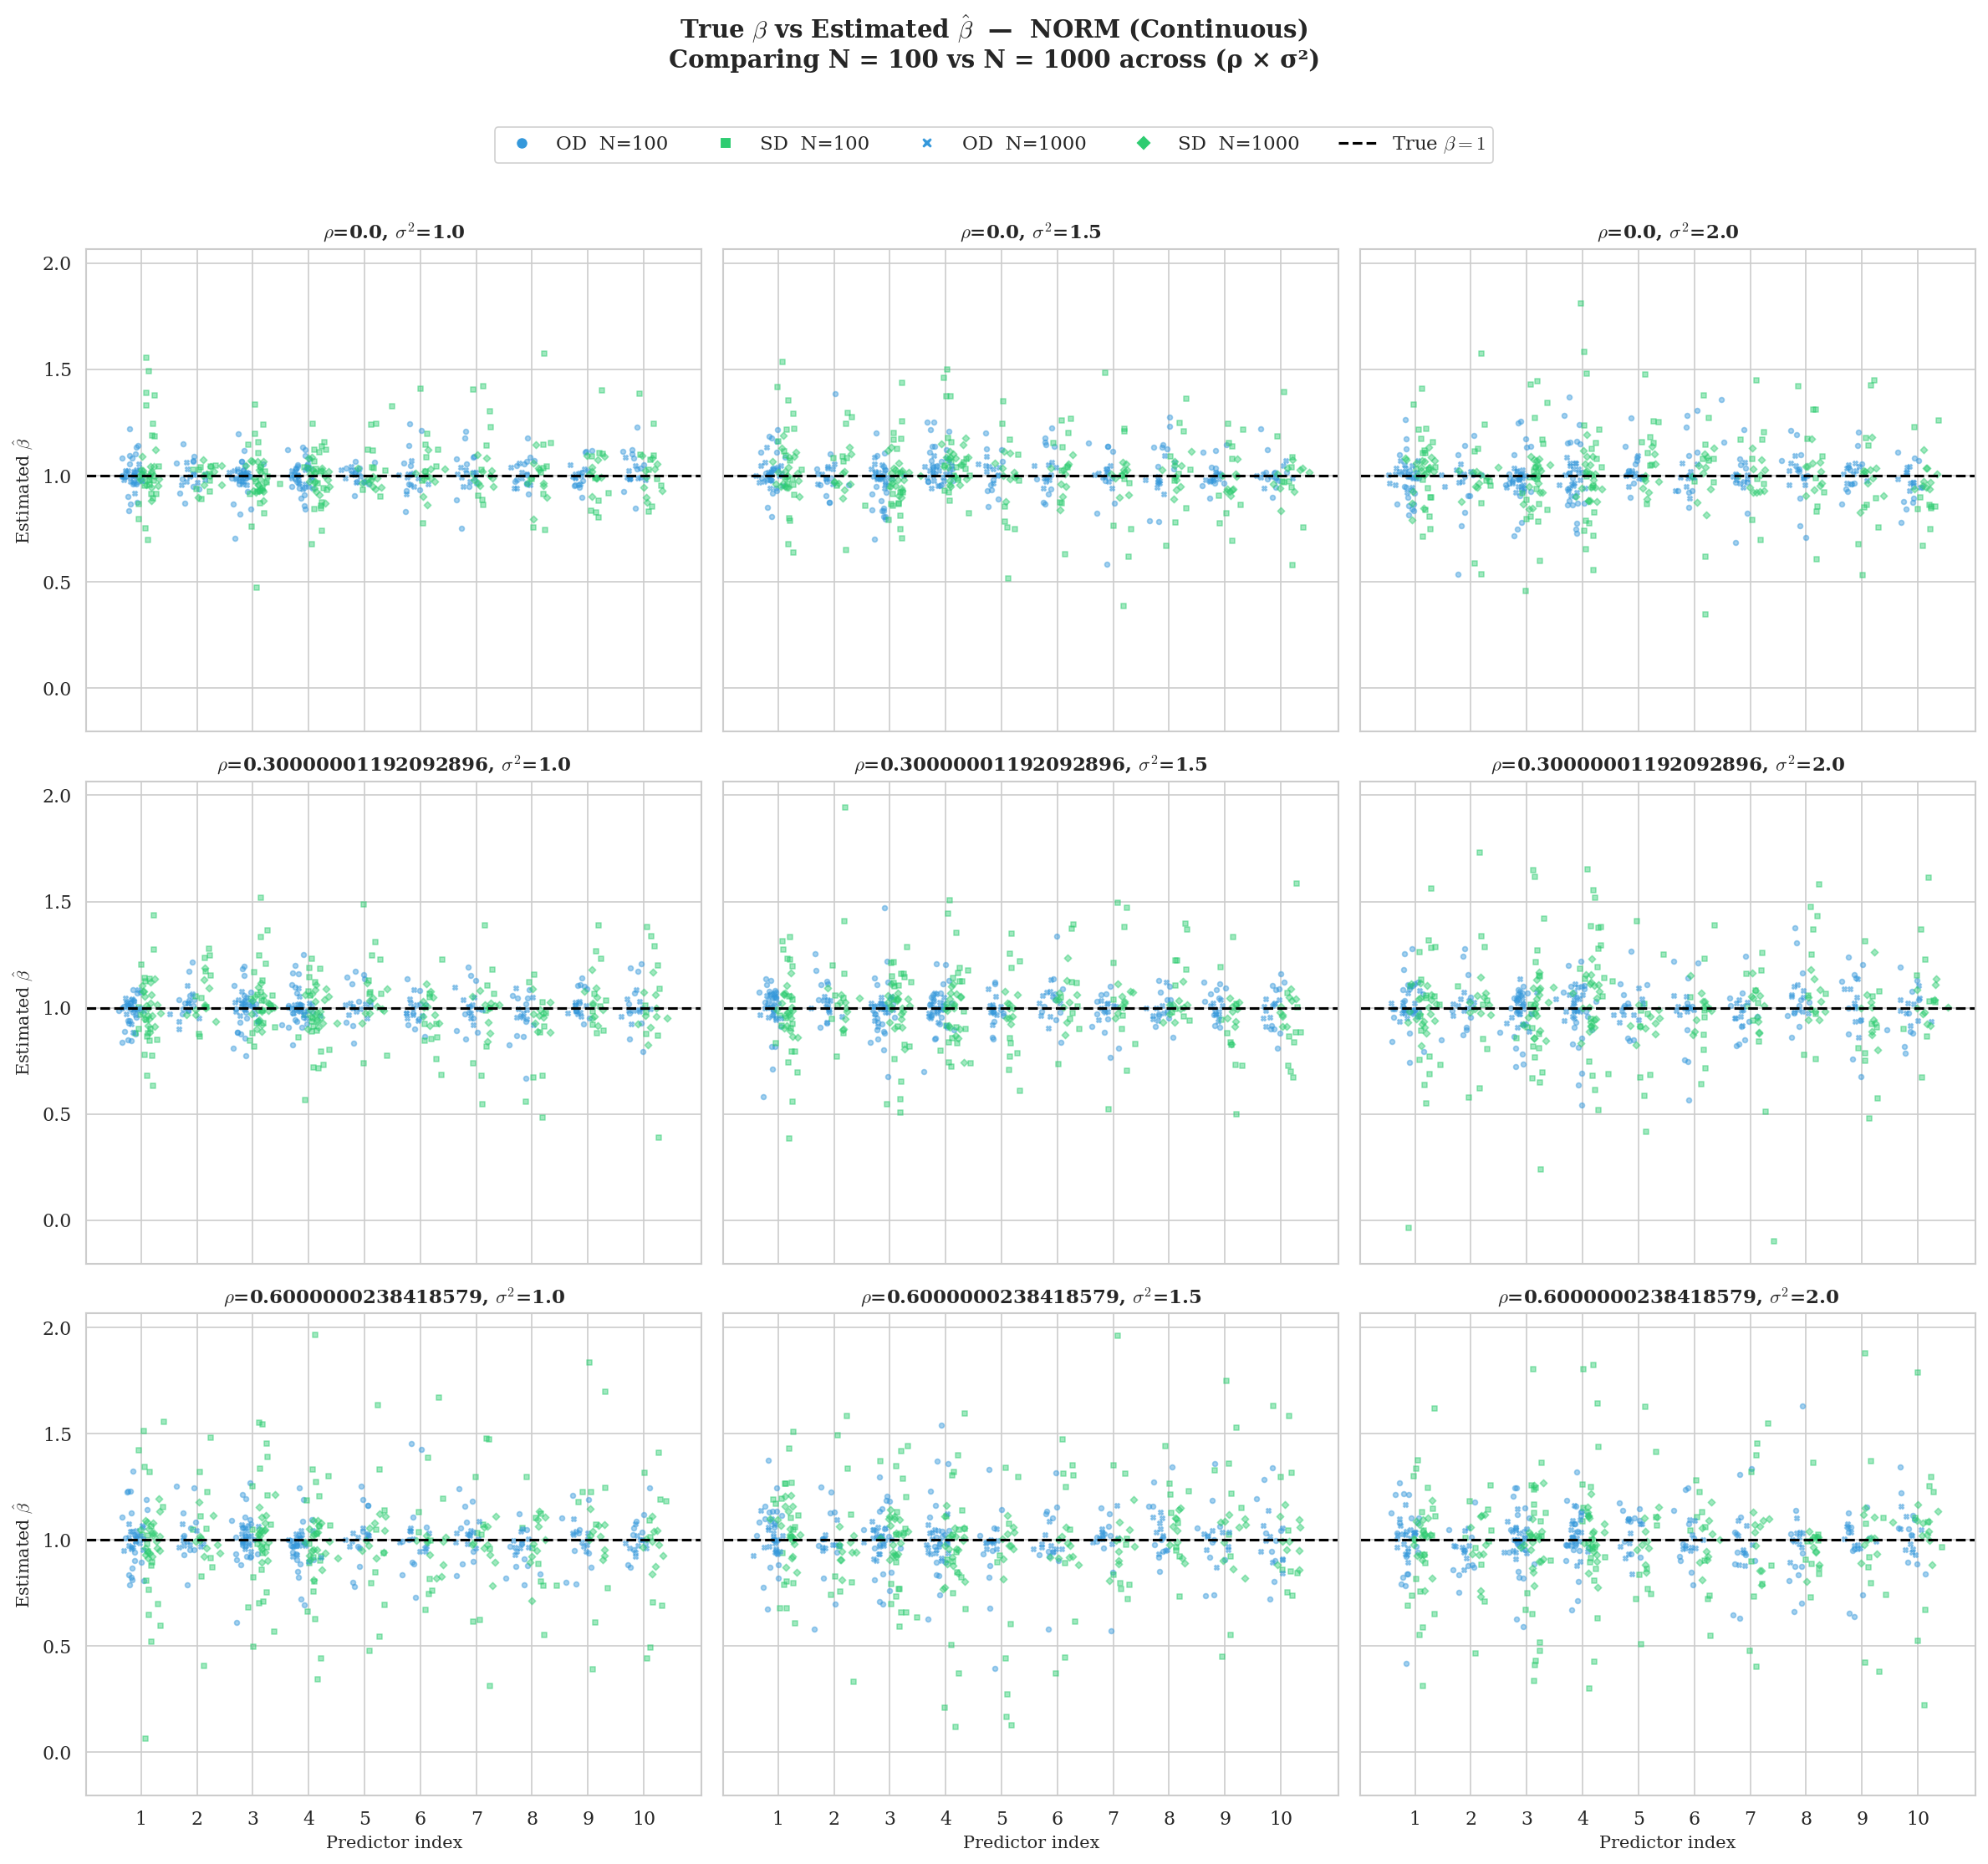

✓ Saved extra_true_vs_est_norm_continuous.png


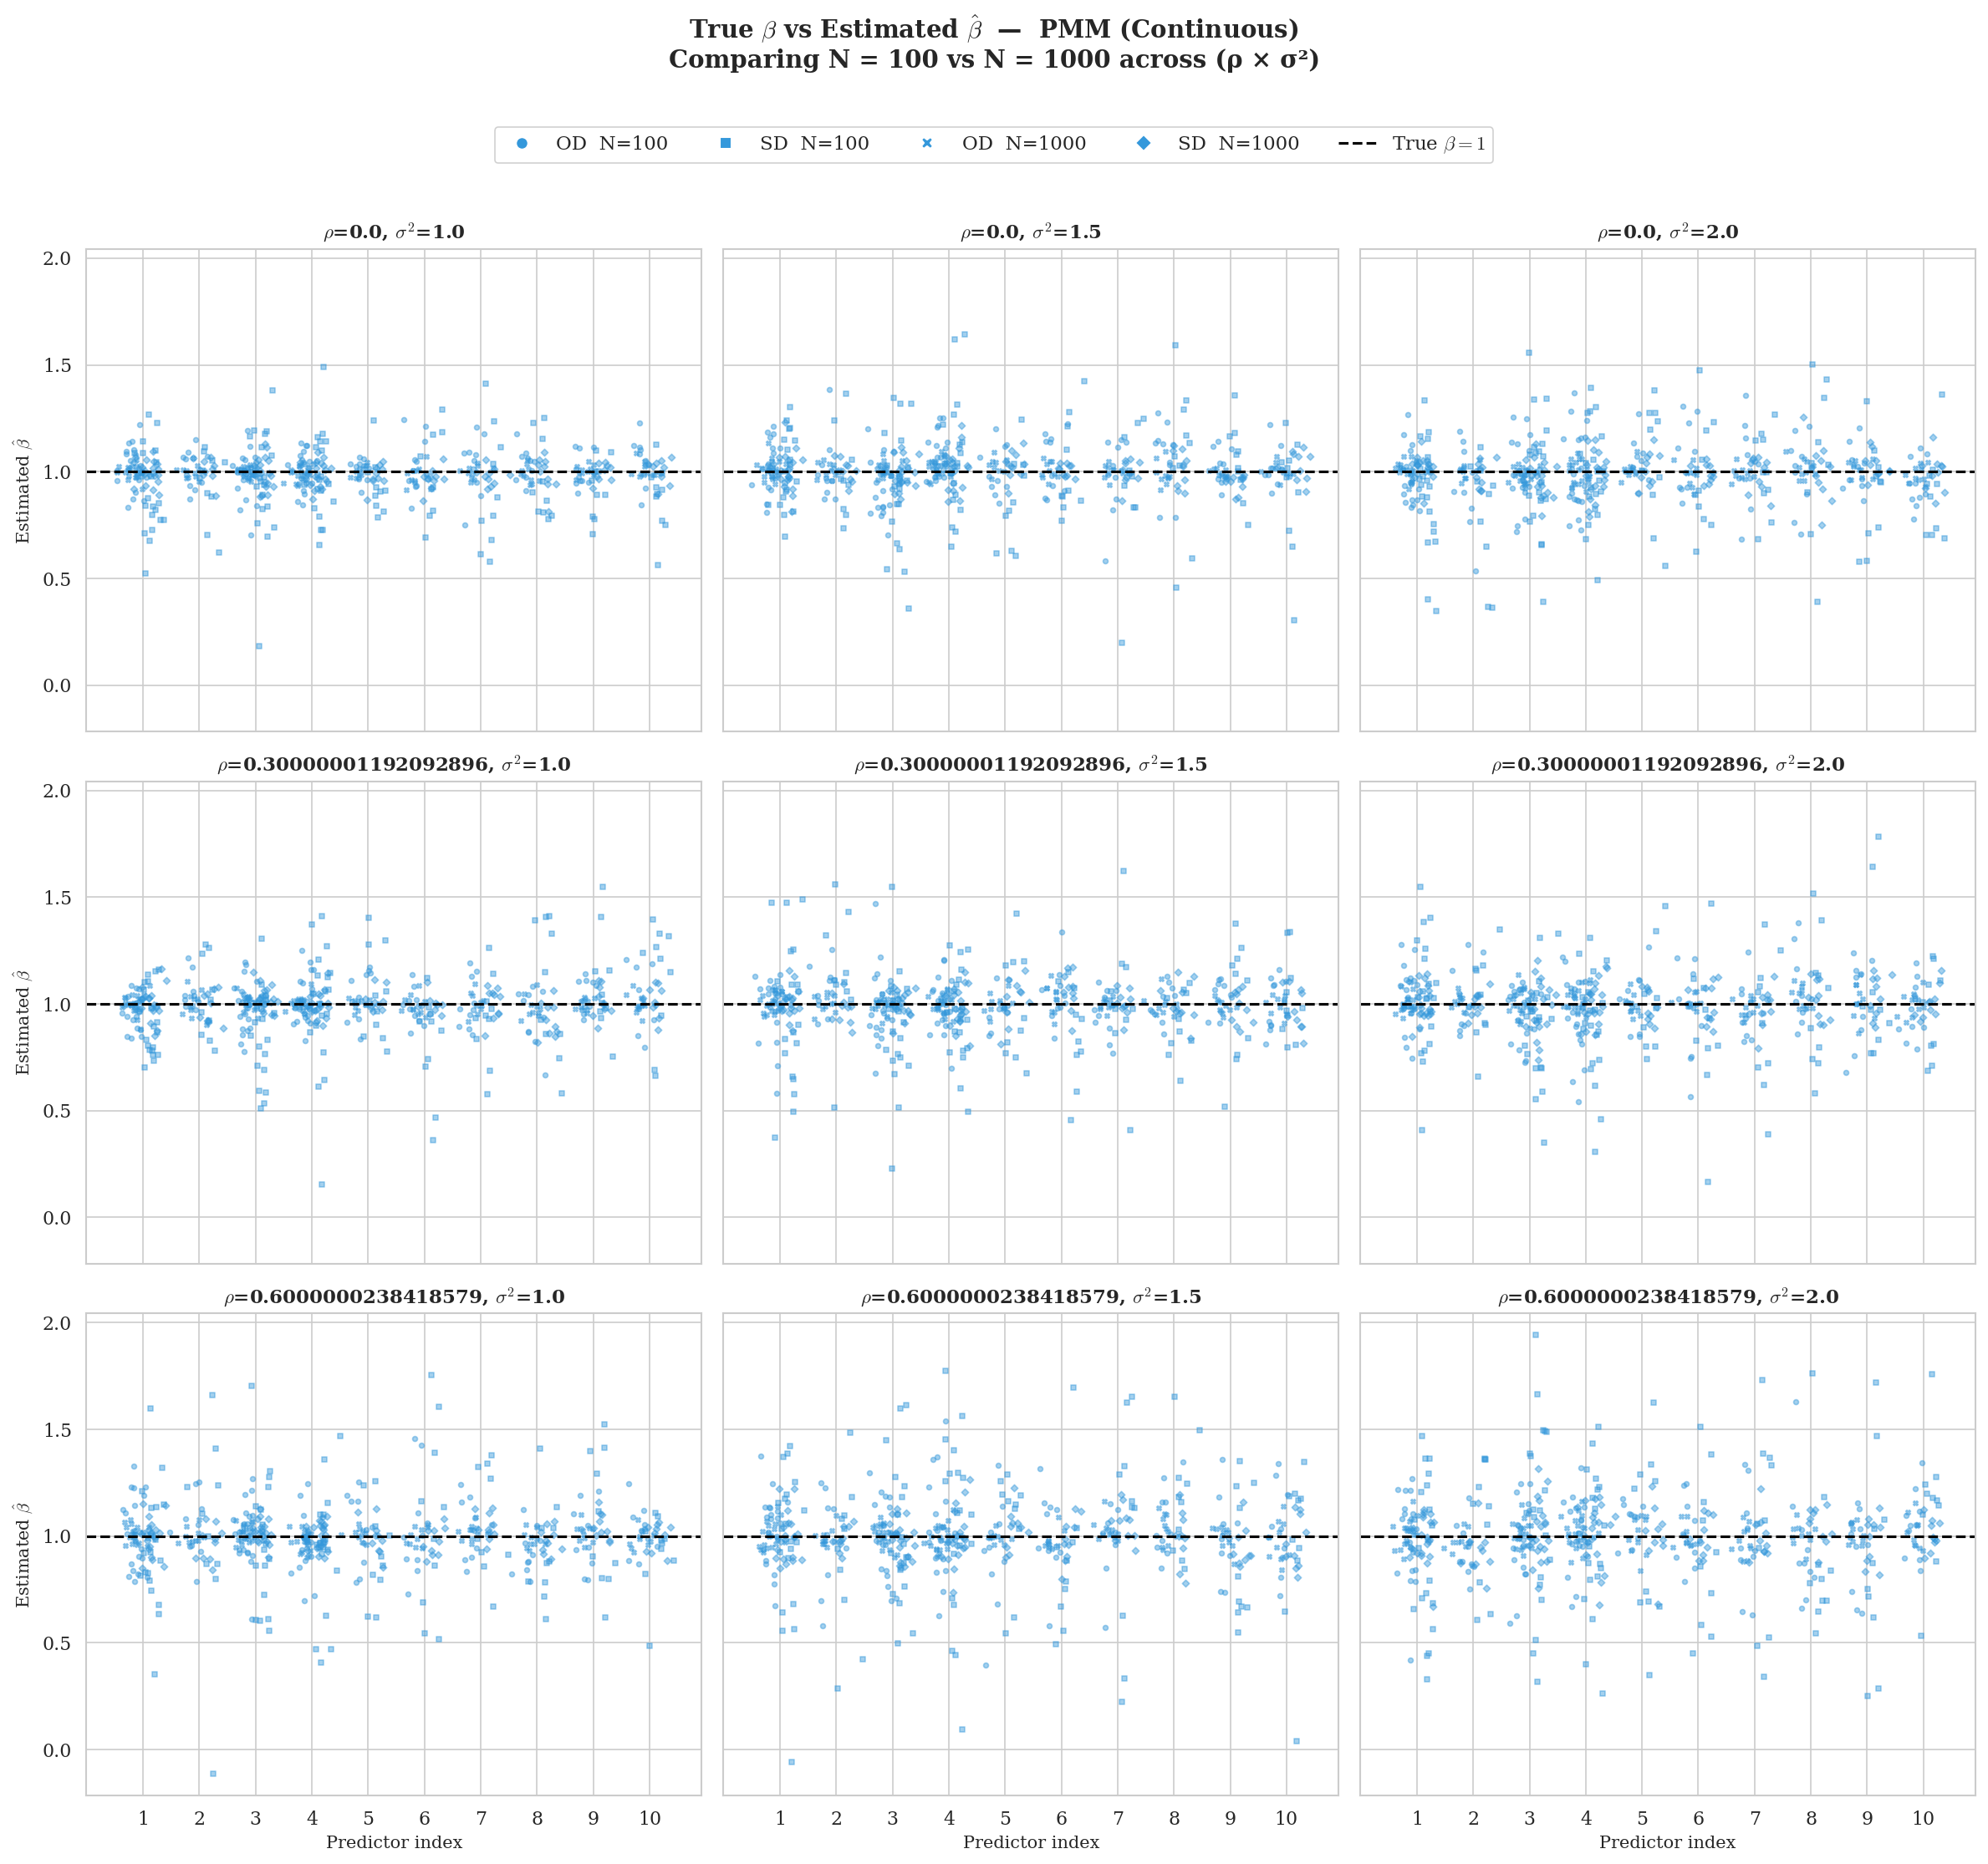

✓ Saved extra_true_vs_est_pmm_continuous.png


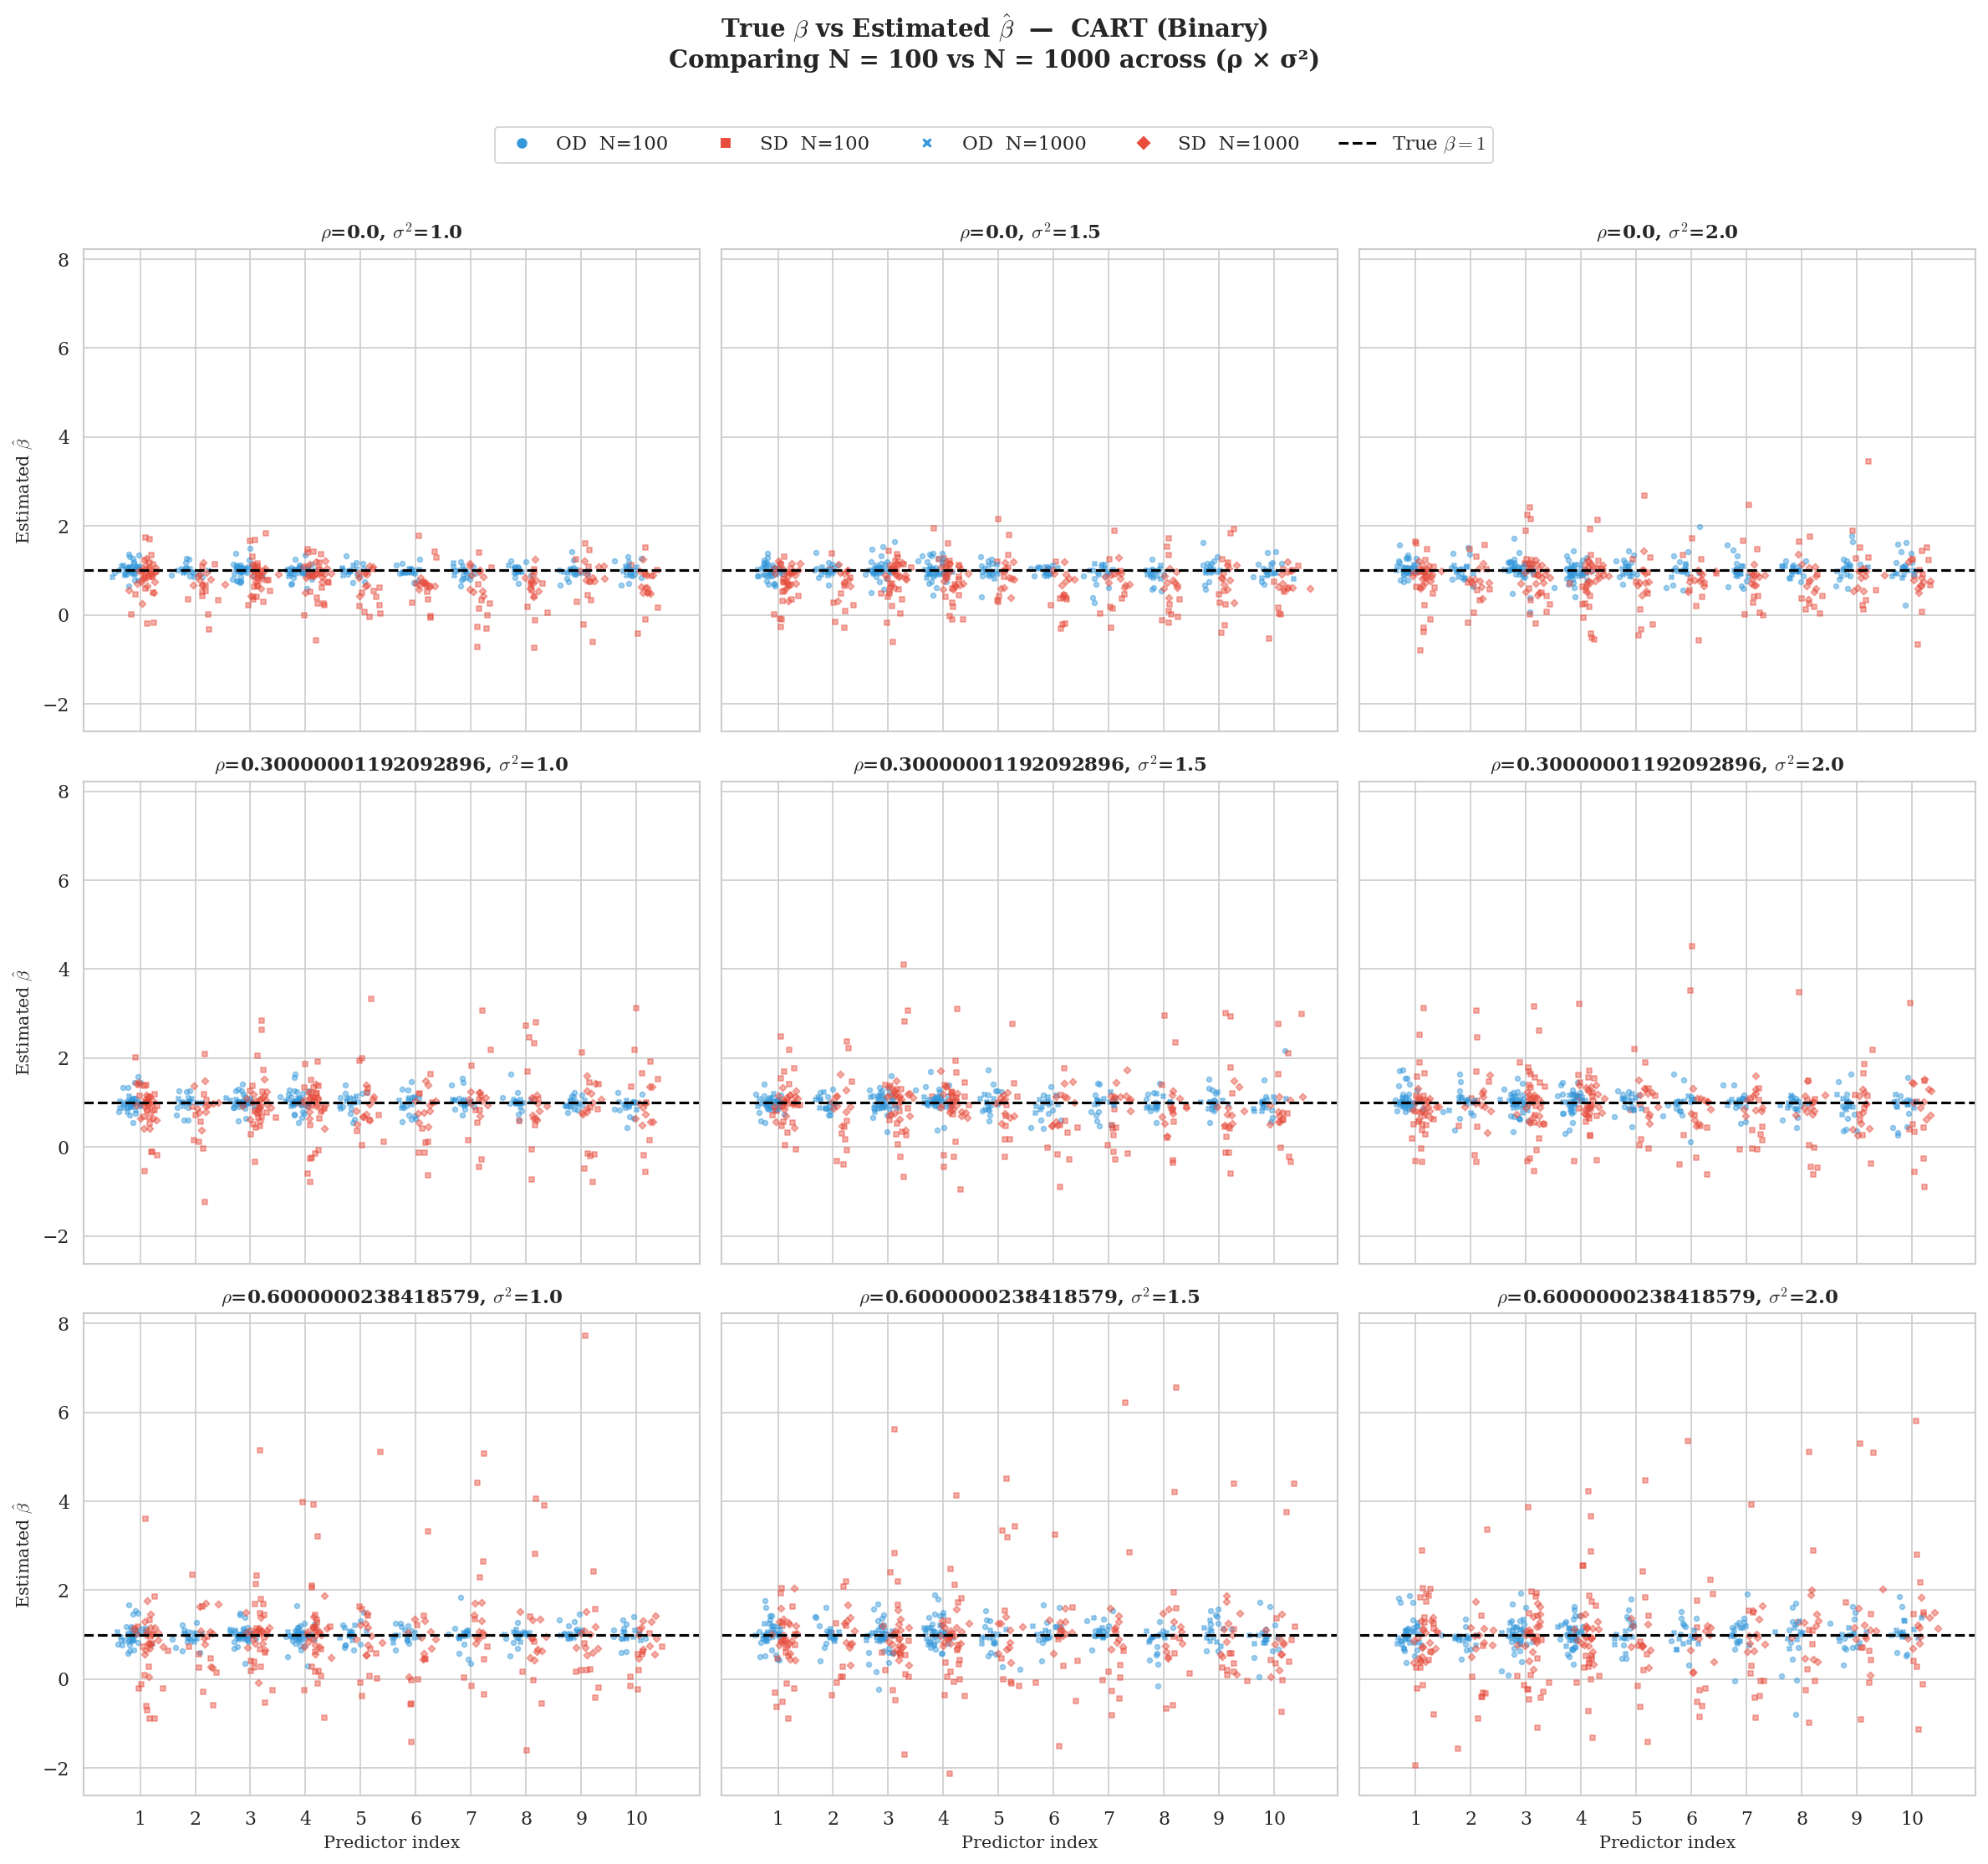

✓ Saved extra_true_vs_est_cart_binary.png


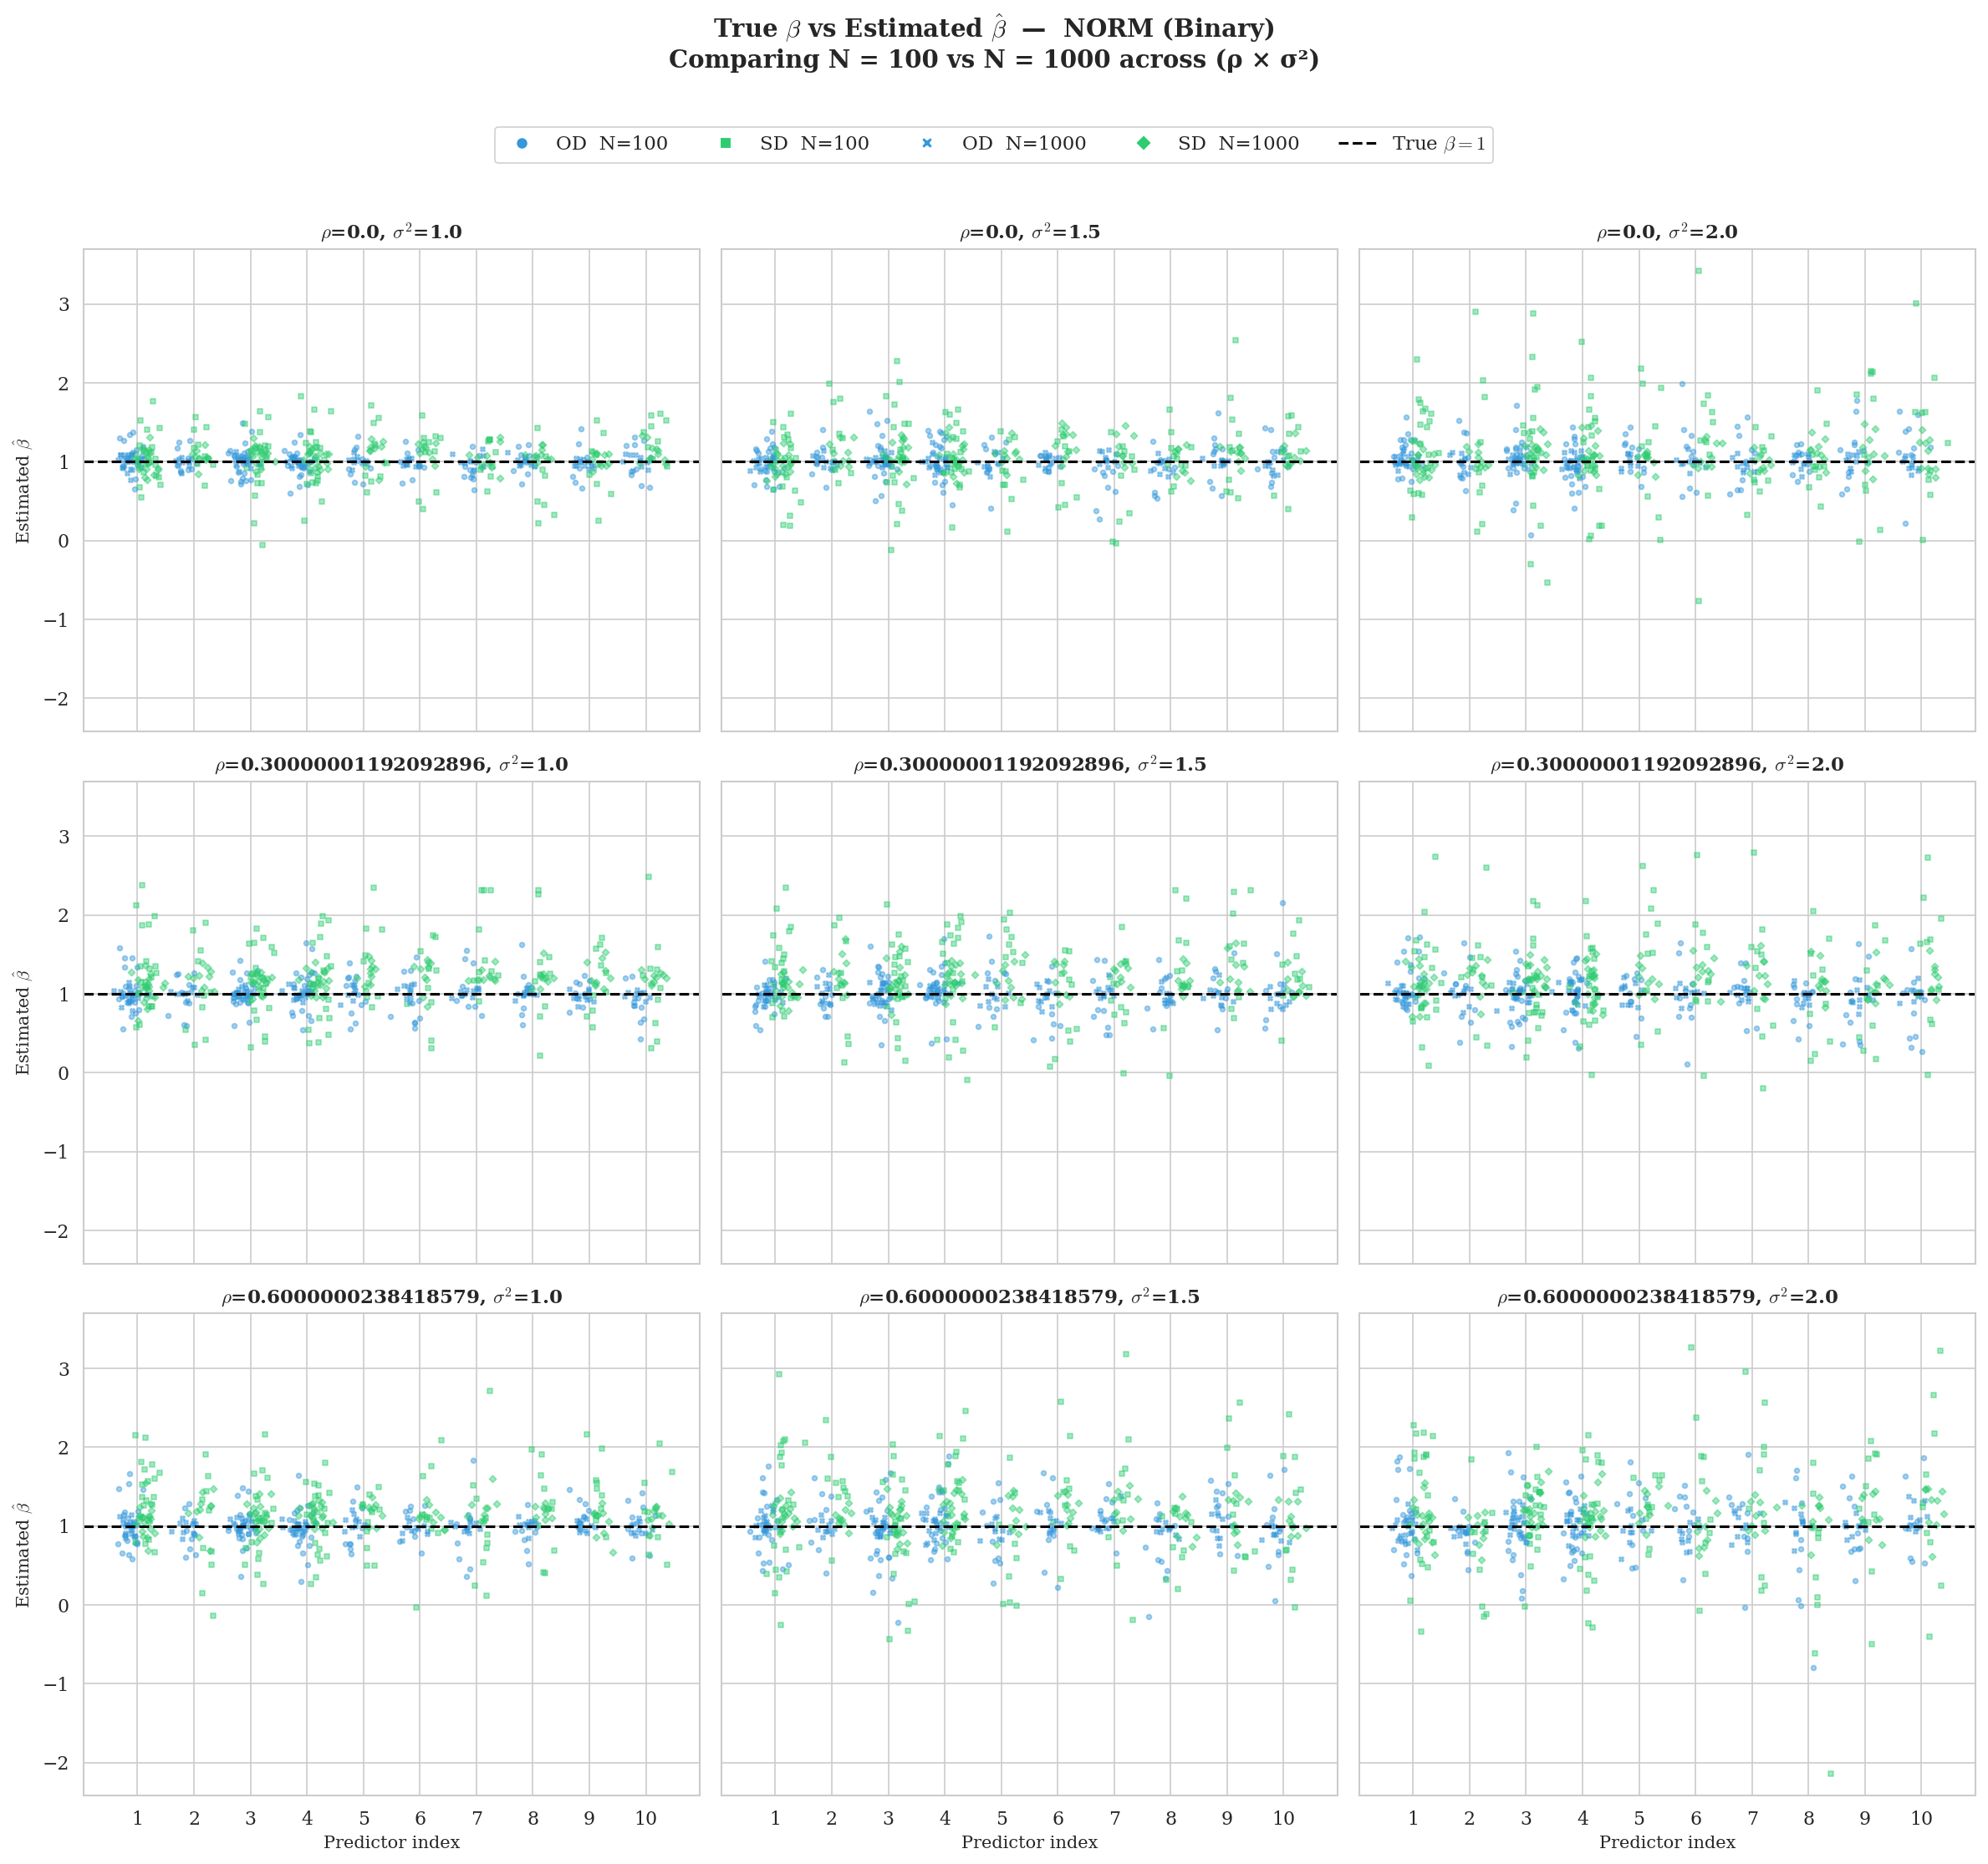

✓ Saved extra_true_vs_est_norm_binary.png


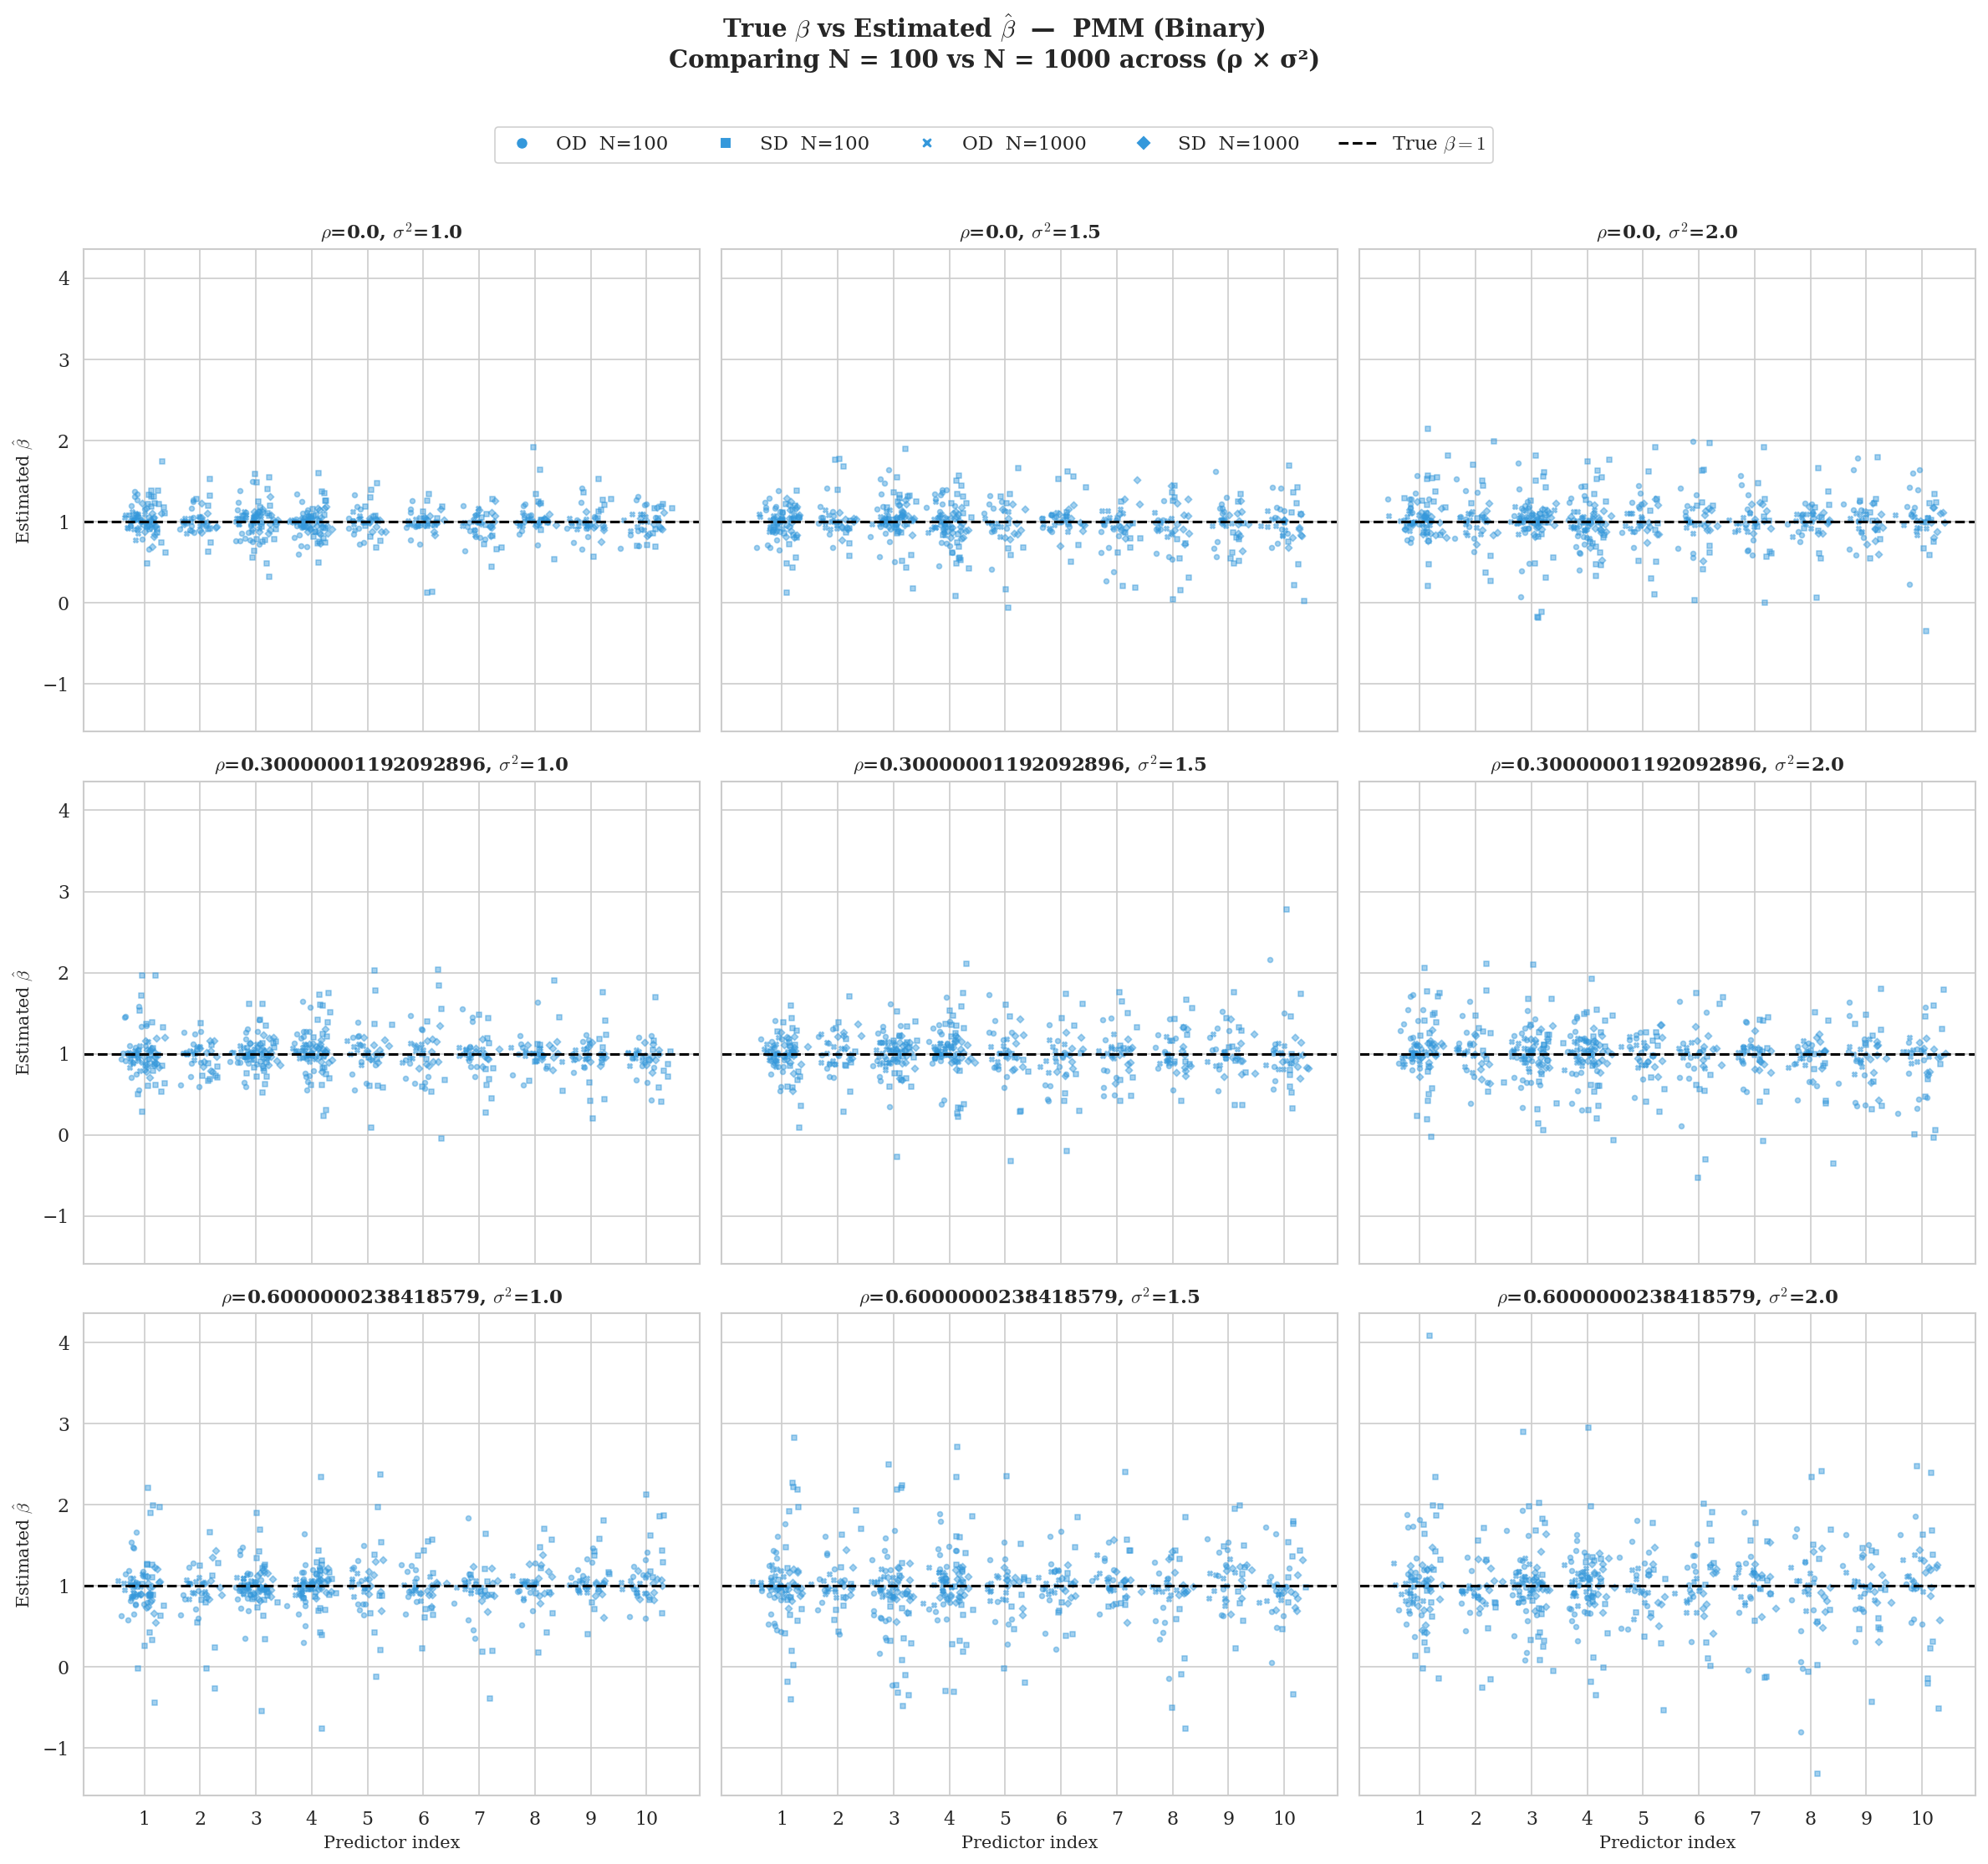

✓ Saved extra_true_vs_est_pmm_binary.png


In [7]:
# ── Plot 2: True β vs β̂ — 3×3 grids per method ──────────────────────────────
#
# Since all true slopes β_j = 1 (j=1..p), we jitter the x-axis by predictor
# index so the scatter is readable. The y-axis shows estimated β̂.

rng = np.random.default_rng(42)
MAX_ITER = 10  # use all iters but subsample within each cell

for vt in ["continuous", "binary"]:
    for m, ml, mcol in zip(methods, method_labels,
                           ["#e74c3c", "#2ecc71", "#3498db"]):
        fig, axes = plt.subplots(3, 3, figsize=(16, 14), sharex=True, sharey=True)

        for ri, rho_val in enumerate(rho_vals):
            for ci, sig_val in enumerate(sigma_vals):
                ax = axes[ri, ci]

                for N_val, marker_od, marker_sd, alpha in [
                    (100,  "o", "s", 0.45),
                    (1000, "X", "D", 0.45),
                ]:
                    sub = df[
                        (df["method"] == m) &
                        (df["var_type"] == vt) &
                        (df["rho"] == rho_val) &
                        (df["sigma_2"] == sig_val) &
                        (df["N"] == N_val)
                    ]

                    # Determine active predictors based on p
                    p_val_mode = sub["p"].mode().iloc[0] if len(sub) > 0 else 10
                    # Use all p values present: get union
                    n_slopes = len(beta_od_slope)

                    b_od = sub[beta_od_slope].values  # (rows, 10)
                    b_sd = sub[beta_sd_slope].values

                    # True beta for slopes = 1.0 each
                    true_b = np.ones(n_slopes)

                    # Build arrays: x = predictor index (jittered), y = β̂
                    n_rows_sub = b_od.shape[0]
                    pred_idx = np.tile(np.arange(1, n_slopes + 1), n_rows_sub)
                    jitter   = rng.normal(0, 0.12, size=pred_idx.shape)

                    y_od = b_od.ravel()
                    y_sd = b_sd.ravel()

                    # Mask NaN (padded predictors)
                    ok_od = ~np.isnan(y_od)
                    ok_sd = ~np.isnan(y_sd)

                    n_label = f"N={N_val}"
                    ax.scatter(
                        pred_idx[ok_od] + jitter[ok_od] - 0.15,
                        y_od[ok_od],
                        c="#3498db", marker=marker_od, s=8, alpha=alpha,
                        label=f"OD {n_label}" if ri == 0 and ci == 0 else "",
                        rasterized=True,
                    )
                    ax.scatter(
                        pred_idx[ok_sd] + jitter[ok_sd] + 0.15,
                        y_sd[ok_sd],
                        c=mcol, marker=marker_sd, s=8, alpha=alpha,
                        label=f"SD {n_label}" if ri == 0 and ci == 0 else "",
                        rasterized=True,
                    )

                # True β reference
                ax.axhline(1.0, color="black", linestyle="--", linewidth=1.5,
                           label="True β = 1" if ri == 0 and ci == 0 else "")

                ax.set_title(rf"$\rho$={rho_val}, $\sigma^2$={sig_val}",
                             fontsize=11, fontweight="bold")
                if ci == 0:
                    ax.set_ylabel(r"Estimated $\hat{\beta}$", fontsize=10)
                if ri == 2:
                    ax.set_xlabel("Predictor index", fontsize=10)
                ax.set_xticks(range(1, n_slopes + 1))

        # Shared legend from first axes
        legend_elements = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#3498db",
                   markersize=7, label="OD  N=100"),
            Line2D([0], [0], marker="s", color="w", markerfacecolor=mcol,
                   markersize=7, label="SD  N=100"),
            Line2D([0], [0], marker="X", color="w", markerfacecolor="#3498db",
                   markersize=7, label="OD  N=1000"),
            Line2D([0], [0], marker="D", color="w", markerfacecolor=mcol,
                   markersize=7, label="SD  N=1000"),
            Line2D([0], [0], color="black", linestyle="--", linewidth=1.5,
                   label=r"True $\beta = 1$"),
        ]
        fig.legend(
            handles=legend_elements, loc="upper center",
            ncol=5, fontsize=11, framealpha=0.9,
            bbox_to_anchor=(0.5, 1.0),
        )

        fig.suptitle(
            rf"True $\beta$ vs Estimated $\hat{{\beta}}$  —  {ml} ({vt.capitalize()})"
            f"\nComparing N = 100 vs N = 1000 across (ρ × σ²)",
            fontsize=14, fontweight="bold", y=1.06,
        )
        plt.tight_layout()
        fname = f"extra_true_vs_est_{m}_{vt}.png"
        fig.savefig(os.path.join(fig_dir, fname))
        plt.show()
        print(f"✓ Saved {fname}")

---

## Plot 3 — CI Overlap Distribution (Violin Plot)

**Research question:** What is the *full distributional shape* of CI Overlap %
across simulation runs — not just the mean?

A split violin plot (N = 100 vs N = 1000) by method, faceted by var_type,
shows whether the overlap is bimodal, skewed, or heavy-tailed.

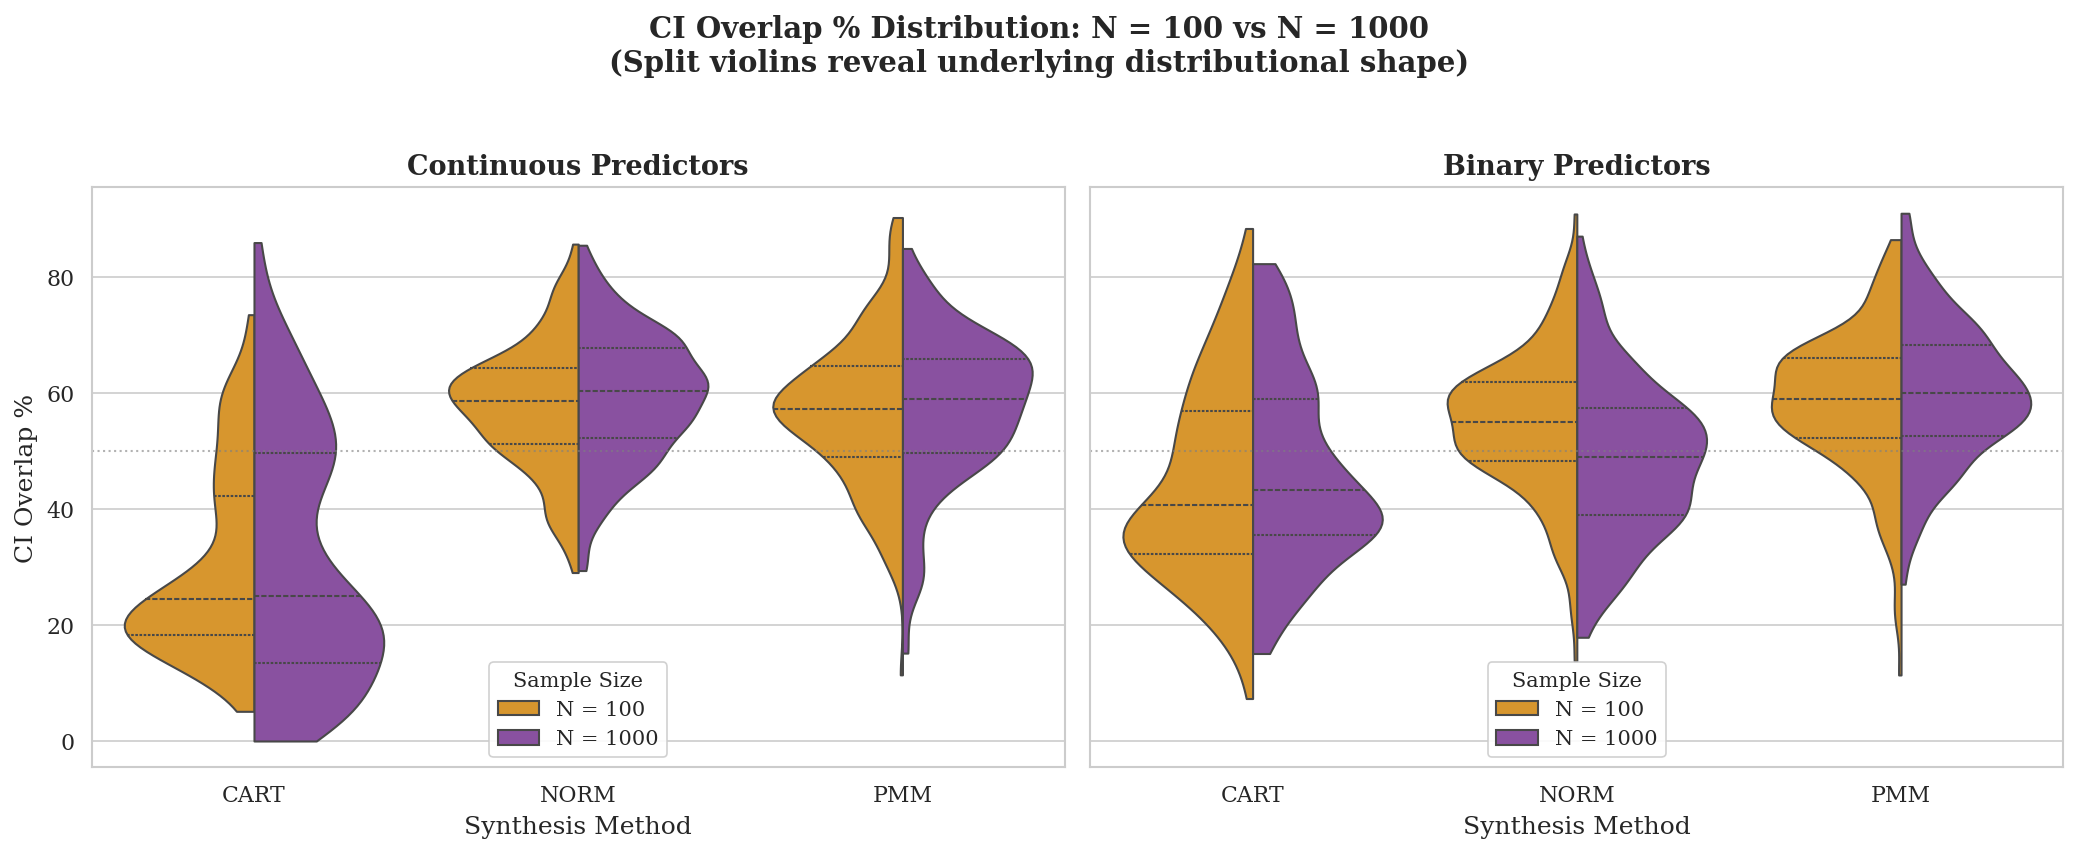

✓ Saved extra_ci_overlap_violin.png


In [8]:
# ── Plot 3: CI Overlap distribution — split violins (N=100 vs N=1000) ────────

plot_v = df.dropna(subset=["ci_overlap_pct"]).copy()
plot_v["Method"]        = plot_v["method"].str.upper()
plot_v["Variable Type"] = plot_v["var_type"].str.capitalize()
plot_v["N_label"]       = "N = " + plot_v["N"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, vt in zip(axes, ["Continuous", "Binary"]):
    subset = plot_v[plot_v["Variable Type"] == vt]
    sns.violinplot(
        data=subset,
        x="Method",
        y="ci_overlap_pct",
        hue="N_label",
        order=["CART", "NORM", "PMM"],
        hue_order=["N = 100", "N = 1000"],
        palette={"N = 100": "#f39c12", "N = 1000": "#8e44ad"},
        split=True,
        inner="quart",
        linewidth=1,
        bw_adjust=0.8,
        cut=0,
        density_norm="width",
        ax=ax,
    )
    ax.axhline(50, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel("Synthesis Method", fontsize=12)
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "", fontsize=12)
    ax.legend(title="Sample Size", fontsize=10, title_fontsize=10, framealpha=0.9)

fig.suptitle(
    "CI Overlap % Distribution: N = 100 vs N = 1000\n"
    "(Split violins reveal underlying distributional shape)",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "extra_ci_overlap_violin.png"))
plt.show()
print("✓ Saved extra_ci_overlap_violin.png")

---

## Plot 4 — Coefficient MAPE by ρ × σ² (Method Comparison)

**Research question:** What is the **mean absolute percentage error** of the
coefficient estimates relative to the true β = 1?

$$\text{MAPE} = \frac{1}{p}\sum_{j=1}^{p} \left|\frac{\hat{\beta}_{SD,j} - \beta_j}{\beta_j}\right| \times 100$$

Line plots by ρ, grouped by method, with panels for each σ² level.

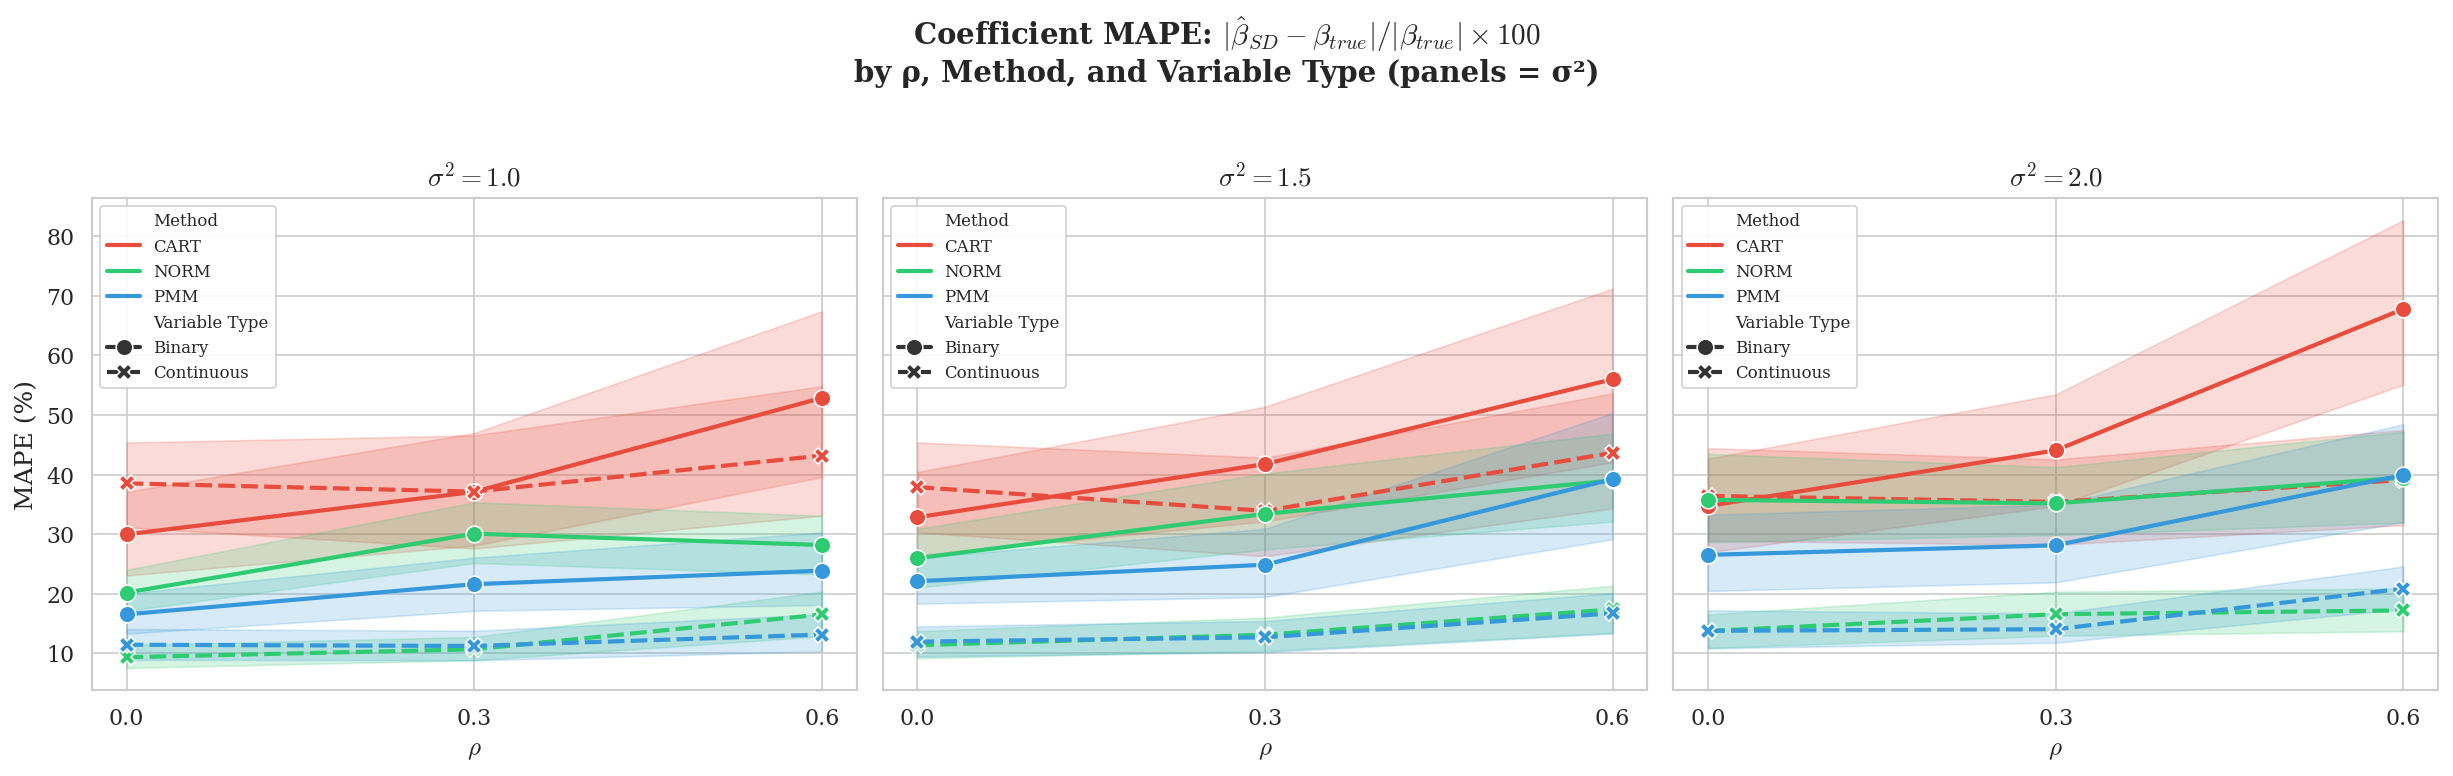

✓ Saved extra_mape_rho_sigma.png


In [9]:
# ── Plot 4: MAPE of SD coefficients vs true β ────────────────────────────────

# True slopes = 1.0 ⇒ MAPE = mean(|β̂_SD - 1| / 1) × 100 = mean(|β̂_SD - 1|) × 100
b_sd_arr = df[beta_sd_slope].values
true_slopes = np.ones(len(beta_sd_slope))

with np.errstate(invalid="ignore"):
    ape = np.abs(b_sd_arr - true_slopes[None, :]) / np.abs(true_slopes[None, :]) * 100

df["mape_sd"] = np.nanmean(ape, axis=1)

plot_mape = df.dropna(subset=["mape_sd"]).copy()
plot_mape["Method"]        = plot_mape["method"].str.upper()
plot_mape["Variable Type"] = plot_mape["var_type"].str.capitalize()

fig, axes = plt.subplots(1, len(sigma_vals), figsize=(5.5 * len(sigma_vals), 5), sharey=True)

for ax, sv in zip(axes, sigma_vals):
    sub = plot_mape[plot_mape["sigma_2"] == sv]
    sns.lineplot(
        data=sub, x="rho", y="mape_sd",
        hue="Method", style="Variable Type",
        hue_order=["CART", "NORM", "PMM"],
        palette=METHOD_PALETTE,
        markers=True, dashes=True,
        errorbar=("ci", 95),
        linewidth=2, markersize=8,
        ax=ax,
    )
    ax.set_title(rf"$\sigma^2 = {sv}$", fontsize=13, fontweight="bold")
    ax.set_xlabel(r"$\rho$", fontsize=12)
    ax.set_ylabel("MAPE (%)" if ax == axes[0] else "", fontsize=12)
    ax.set_xticks(rho_vals)
    ax.legend(fontsize=8, title_fontsize=9, framealpha=0.9)

fig.suptitle(
    r"Coefficient MAPE: $|\hat{\beta}_{SD} - \beta_{true}| / |\beta_{true}| \times 100$"
    "\nby ρ, Method, and Variable Type (panels = σ²)",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "extra_mape_rho_sigma.png"))
plt.show()
print("✓ Saved extra_mape_rho_sigma.png")

---

## Plot 5 — CI Width Ratio: How Much Wider/Narrower Are the Synthetic CIs?

**Research question:** Does synthesis systematically change the *width* of
confidence intervals?

$$\text{CI Width Ratio}_j = \frac{\text{Width}_{SD,j}}{\text{Width}_{OD,j}} = \frac{SE_{SD,j}}{SE_{OD,j}}$$

A ratio of 1 = perfect preservation. Values > 1 mean the synthetic CI is wider
(conservative); < 1 means the synthetic CI is narrower (overconfident).

Faceted heatmap: mean CI width ratio by (ρ × σ²) per method.

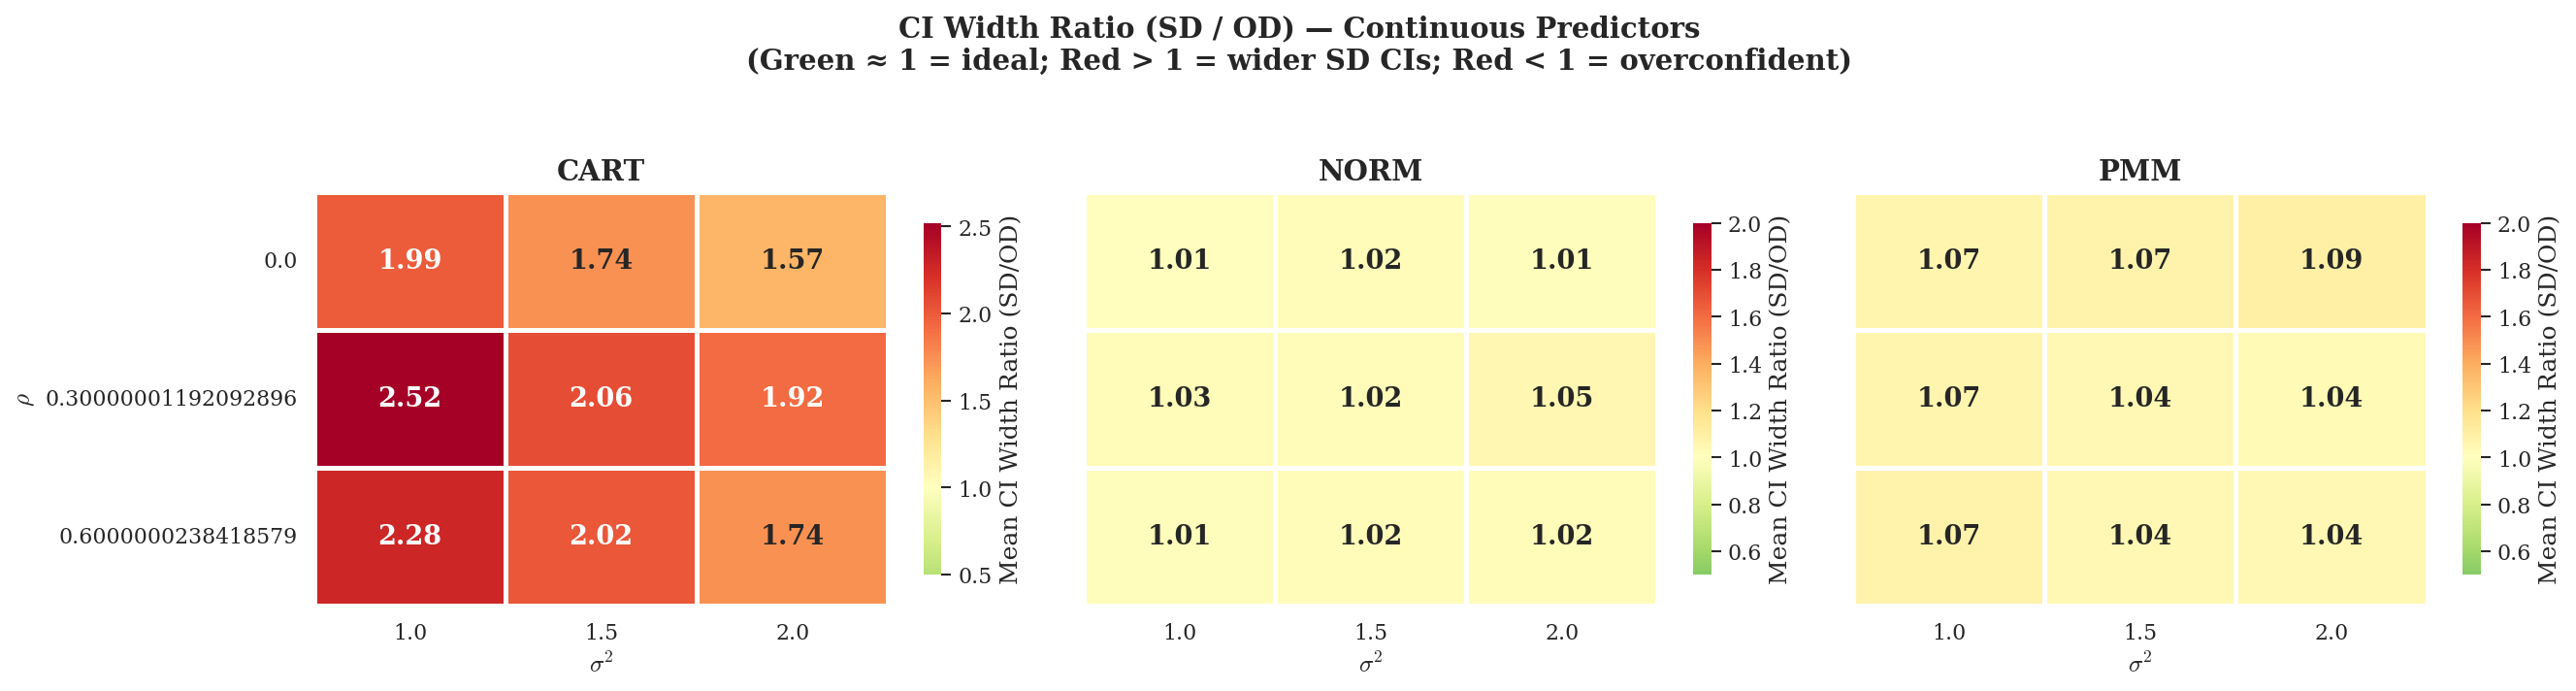

✓ Saved extra_ci_width_ratio_continuous.png


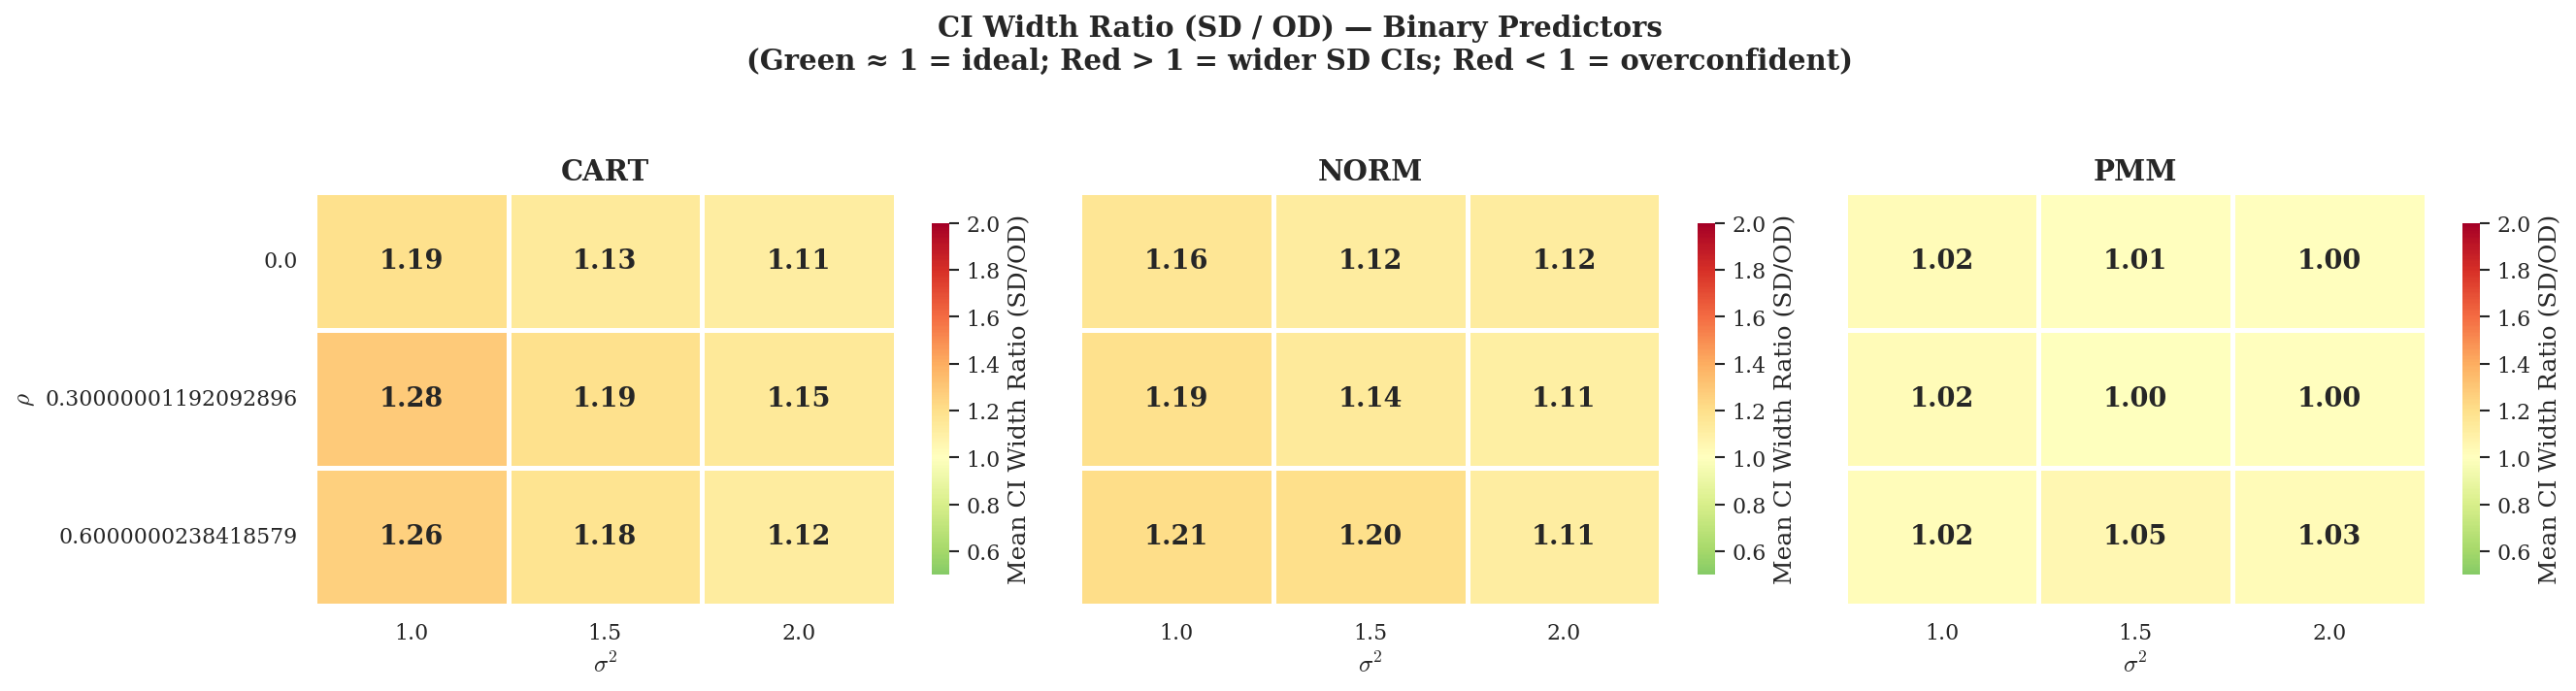

✓ Saved extra_ci_width_ratio_binary.png


In [10]:
# ── Plot 5: CI Width Ratio heatmaps (method × ρ × σ²) ───────────────────────

se_od_arr = df[se_od_slope].values
se_sd_arr = df[se_sd_slope].values

with np.errstate(divide="ignore", invalid="ignore"):
    ci_width_ratio = np.where(
        (se_od_arr > 0) & ~np.isnan(se_od_arr) & ~np.isnan(se_sd_arr),
        se_sd_arr / se_od_arr,
        np.nan,
    )

df["mean_ci_width_ratio"] = np.nanmean(ci_width_ratio, axis=1)

for vt in ["continuous", "binary"]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

    for ax, m, ml in zip(axes, methods, method_labels):
        sub = df[(df["method"] == m) & (df["var_type"] == vt)]
        pivot = (
            sub.groupby(["rho", "sigma_2"])["mean_ci_width_ratio"]
               .mean()
               .unstack("sigma_2")
               .reindex(index=rho_vals, columns=sigma_vals)
        )
        # Diverging palette around 1.0
        vmin = min(0.5, pivot.min().min())
        vmax = max(2.0, pivot.max().max())
        sns.heatmap(
            pivot, ax=ax,
            annot=True, fmt=".2f",
            cmap="RdYlGn_r", center=1.0, vmin=vmin, vmax=vmax,
            linewidths=1.5, linecolor="white",
            cbar_kws={"label": "Mean CI Width Ratio (SD/OD)", "shrink": 0.85},
            annot_kws={"fontsize": 13, "fontweight": "bold"},
        )
        ax.set_title(ml, fontsize=14, fontweight="bold")
        ax.set_xlabel(r"$\sigma^2$", fontsize=12)
        ax.set_ylabel(r"$\rho$" if ax == axes[0] else "", fontsize=12)
        ax.tick_params(axis="y", labelrotation=0)

    fig.suptitle(
        rf"CI Width Ratio (SD / OD) — {vt.capitalize()} Predictors"
        "\n(Green ≈ 1 = ideal; Red > 1 = wider SD CIs; Red < 1 = overconfident)",
        fontsize=14, fontweight="bold", y=1.05,
    )
    plt.tight_layout()
    fname = f"extra_ci_width_ratio_{vt}.png"
    fig.savefig(os.path.join(fig_dir, fname))
    plt.show()
    print(f"✓ Saved {fname}")

---

## Plot 6 — Bias Direction: Does Synthesis Overestimate or Underestimate?

**Research question:** Is the synthesis error *symmetric* around zero, or is there
a directional bias?

For each predictor and scenario:
$$\text{Signed Bias}_j = \hat{\beta}_{SD,j} - \hat{\beta}_{OD,j}$$

A raincloud plot (half-violin + strip) reveals skewness in the bias distribution.

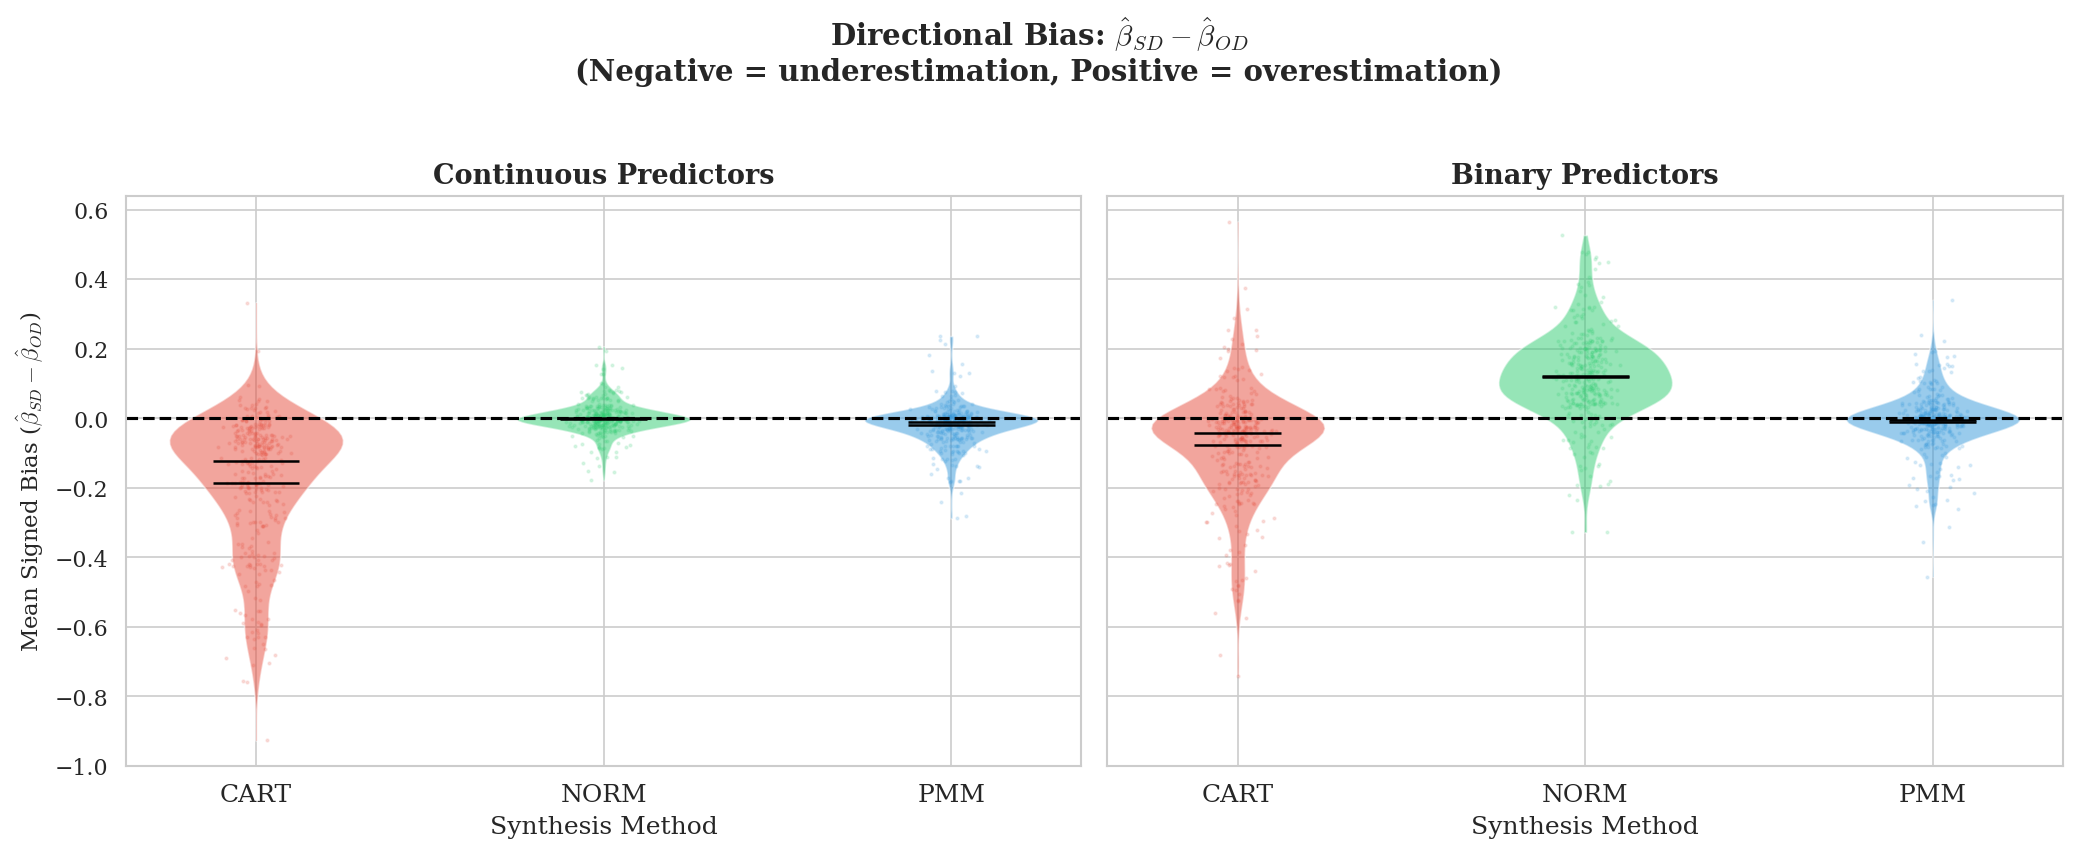

✓ Saved extra_signed_bias_raincloud.png


In [11]:
# ── Plot 6: Signed Bias raincloud ────────────────────────────────────────────

b_od_arr = df[beta_od_slope].values
b_sd_arr2 = df[beta_sd_slope].values
signed_bias = b_sd_arr2 - b_od_arr  # (rows, 10)

# Mean signed bias per scenario
df["mean_signed_bias"] = np.nanmean(signed_bias, axis=1)

plot_bias = df.dropna(subset=["mean_signed_bias"]).copy()
plot_bias["Method"]        = plot_bias["method"].str.upper()
plot_bias["Variable Type"] = plot_bias["var_type"].str.capitalize()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, vt in zip(axes, ["Continuous", "Binary"]):
    sub = plot_bias[plot_bias["Variable Type"] == vt]

    # Half-violin
    parts = ax.violinplot(
        [sub[sub["Method"] == m]["mean_signed_bias"].values for m in METHOD_ORDER],
        positions=range(len(METHOD_ORDER)),
        showmeans=True, showmedians=True, showextrema=False,
    )
    for pc, col in zip(parts["bodies"], ["#e74c3c", "#2ecc71", "#3498db"]):
        pc.set_facecolor(col)
        pc.set_alpha(0.5)
    parts["cmeans"].set_color("black")
    parts["cmedians"].set_color("black")

    # Strip jitter
    for i, m in enumerate(METHOD_ORDER):
        vals = sub[sub["Method"] == m]["mean_signed_bias"].values
        jit  = rng.normal(0, 0.04, len(vals))
        col  = METHOD_PALETTE[m]
        ax.scatter(i + jit, vals, c=col, s=1.5, alpha=0.15, rasterized=True)

    ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    ax.set_xticks(range(len(METHOD_ORDER)))
    ax.set_xticklabels(METHOD_ORDER, fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.set_xlabel("Synthesis Method", fontsize=12)
    ax.set_ylabel(r"Mean Signed Bias ($\hat{\beta}_{SD} - \hat{\beta}_{OD}$)"
                  if ax == axes[0] else "", fontsize=11)

fig.suptitle(
    r"Directional Bias: $\hat{\beta}_{SD} - \hat{\beta}_{OD}$"
    "\n(Negative = underestimation, Positive = overestimation)",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "extra_signed_bias_raincloud.png"))
plt.show()
print("✓ Saved extra_signed_bias_raincloud.png")

---

## Plot 7 — CI Overlap vs Euclidean Distance (Scatter Diagnostic)

**Research question:** How tightly correlated are these two fidelity metrics?
Are there scenarios where CI overlap is high but Euclidean distance is also high
(i.e., the intervals overlap by accident despite shifted centres)?

Each point is a single scenario (method × var_type × parameters × iter).

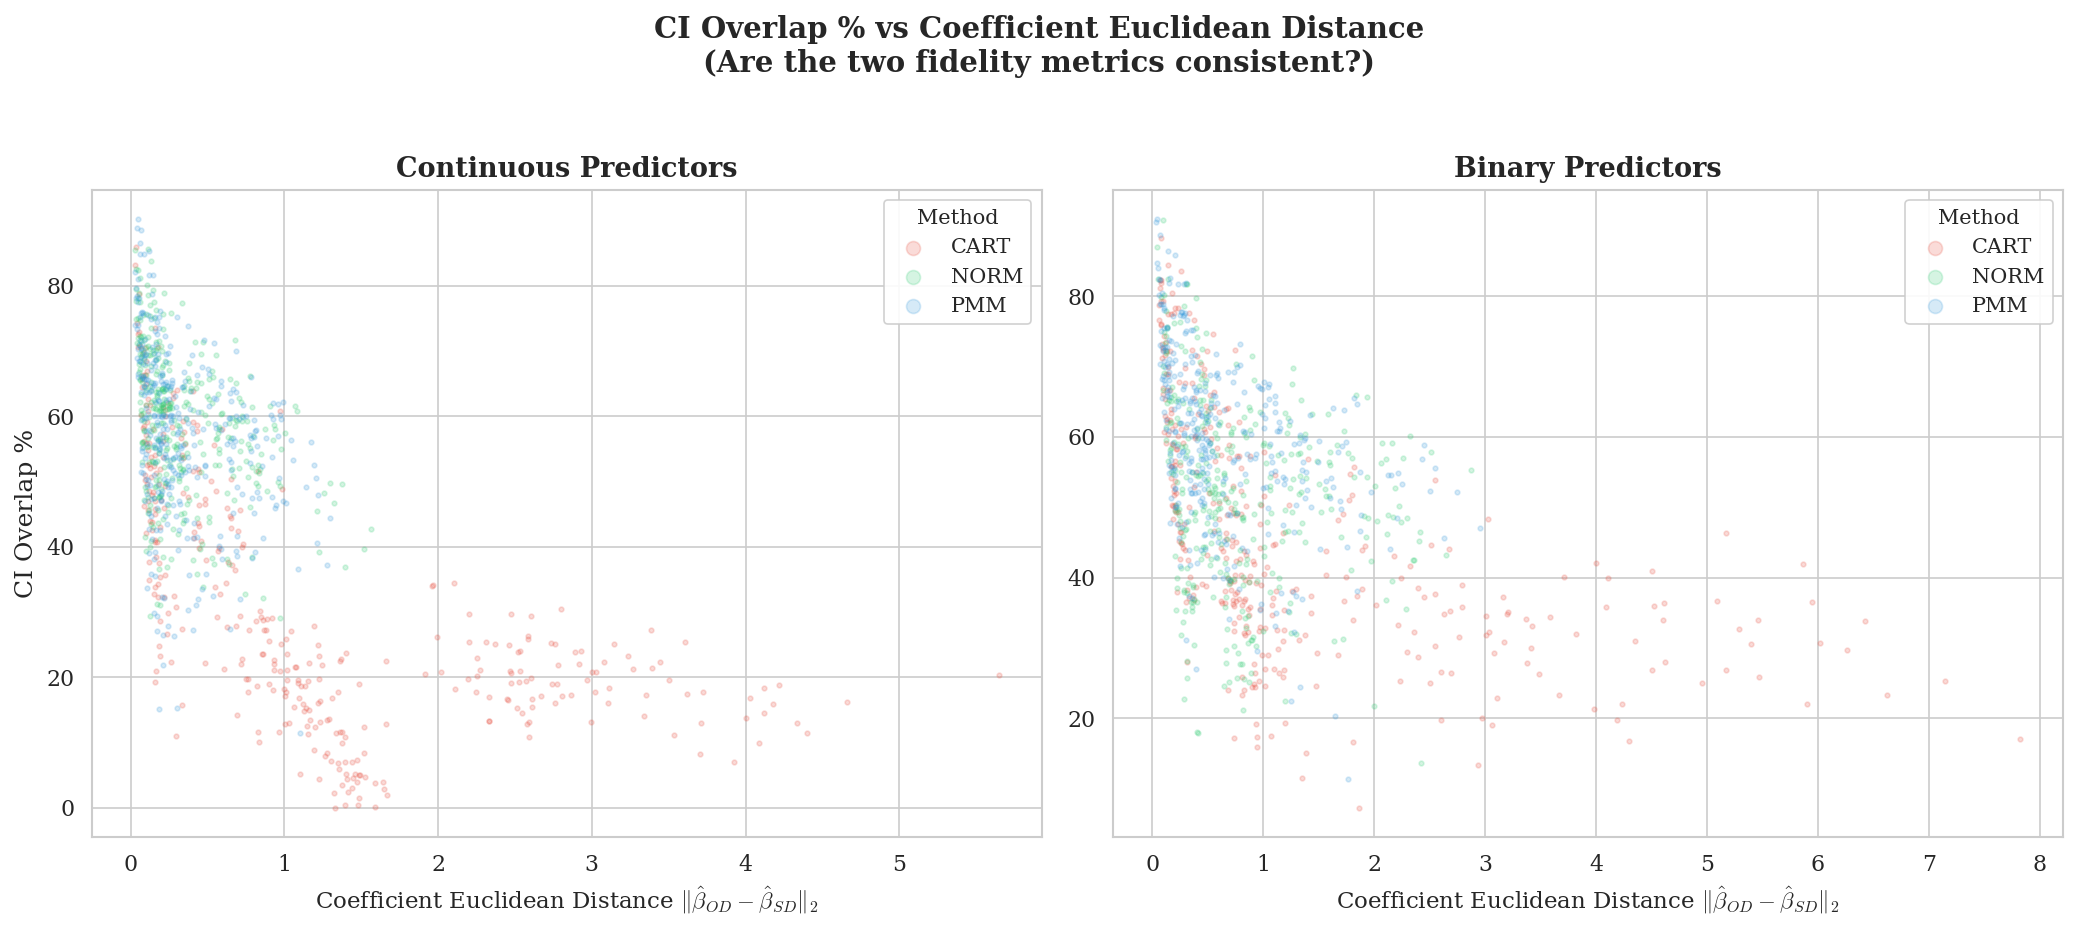

✓ Saved extra_ci_overlap_vs_eucl_scatter.png


In [12]:
# ── Plot 7: CI Overlap % vs Coefficient Euclidean Distance ────────────────────

# Compute Euclidean distance if not already present
if "coef_eucl_dist" not in df.columns:
    beta_diff = df[beta_od_slope].values - df[beta_sd_slope].values
    df["coef_eucl_dist"] = np.sqrt(np.nansum(beta_diff ** 2, axis=1))

plot_sc = df.dropna(subset=["ci_overlap_pct", "coef_eucl_dist"]).copy()
plot_sc["Method"]        = plot_sc["method"].str.upper()
plot_sc["Variable Type"] = plot_sc["var_type"].str.capitalize()

# Subsample for performance
plot_sc = plot_sc.sample(n=min(40_000, len(plot_sc)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, vt in zip(axes, ["Continuous", "Binary"]):
    sub = plot_sc[plot_sc["Variable Type"] == vt]
    for m in METHOD_ORDER:
        msub = sub[sub["Method"] == m]
        ax.scatter(
            msub["coef_eucl_dist"], msub["ci_overlap_pct"],
            c=METHOD_PALETTE[m], s=5, alpha=0.2,
            label=m, rasterized=True,
        )
    ax.set_xlabel(r"Coefficient Euclidean Distance $\|\hat{\beta}_{OD} - \hat{\beta}_{SD}\|_2$",
                  fontsize=11)
    ax.set_ylabel("CI Overlap %" if ax == axes[0] else "", fontsize=12)
    ax.set_title(f"{vt} Predictors", fontsize=13, fontweight="bold")
    ax.legend(title="Method", fontsize=10, title_fontsize=10,
              markerscale=3, framealpha=0.9)

fig.suptitle(
    "CI Overlap % vs Coefficient Euclidean Distance\n"
    "(Are the two fidelity metrics consistent?)",
    fontsize=14, fontweight="bold", y=1.03,
)
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "extra_ci_overlap_vs_eucl_scatter.png"))
plt.show()
print("✓ Saved extra_ci_overlap_vs_eucl_scatter.png")

---

## Summary Statistics

In [13]:
# ── Grand summary table ──────────────────────────────────────────────────────

extra_summary = (
    df.dropna(subset=["ci_overlap_pct"])
      .groupby(["method", "var_type"])
      .agg(
          n = ("ci_overlap_pct", "count"),
          ci_overlap_mean   = ("ci_overlap_pct", "mean"),
          ci_overlap_median = ("ci_overlap_pct", "median"),
          ci_overlap_std    = ("ci_overlap_pct", "std"),
          mape_sd_mean      = ("mape_sd", "mean"),
          mape_sd_std       = ("mape_sd", "std"),
          ci_width_ratio_mean = ("mean_ci_width_ratio", "mean"),
          signed_bias_mean    = ("mean_signed_bias", "mean"),
      )
      .round(3)
)

print("=" * 80)
print("EXTRA EVALUATION SUMMARY")
print("=" * 80)
display(extra_summary)

extra_summary.to_csv(os.path.join(result_dir, "extra_evaluation_summary.csv"))
print(f"\n✓ Saved to results/extra_evaluation_summary.csv")
print("\n✓ Notebook 04_extra complete.")

EXTRA EVALUATION SUMMARY


n  ci_overlap_mean  ci_overlap_median  ci_overlap_std  \
method var_type                                                              
cart   binary      360           45.424             42.433          16.612   
       continuous  360           30.755             24.894          19.035   
norm   binary      360           51.654             52.109          13.339   
       continuous  360           58.397             59.093          10.954   
pmm    binary      360           59.133             59.235          12.214   
       continuous  360           56.904             57.844          12.979   

                   mape_sd_mean  mape_sd_std  ci_width_ratio_mean  \
method var_type                                                     
cart   binary            44.117       36.876                1.178   
       continuous        38.350       27.868                1.984   
norm   binary            31.909       21.066                1.150   
       continuous        13.974       10.306                1.021   
pmm    binary            26.967       22.257                1.017   
       continuous        13.968        9.983                1.059   

                   signed_bias_mean  
method var_type                      
cart   binary                -0.078  
       continuous            -0.186  
norm   binary                 0.121  
       continuous             0.001  
pmm    binary                -0.010  
       continuous            -0.019


✓ Saved to results/extra_evaluation_summary.csv

✓ Notebook 04_extra complete.
